# Closed-Loop Repertoire Experiment Analysis

Loads results from `outputs/data_system_sim_0.05scale/test_repertoire_run2/` and shows:
1. **Raster + stim electrode panel** – first 1 000 ms of the closed-loop run
2. **PCA manifold** – pre/post-stim trajectories in the orientation-tuning PC space, coloured by experiment time

In [ ]:
import glob
import os
import pickle

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ── paths ──────────────────────────────────────────────────────────────────
DATA_DIR = "outputs/data_system_sim_0.05scale/closed_loop_orientation180_10msinterval_learning_180"
if not os.path.exists(os.path.join(DATA_DIR, "viz")):
    os.makedirs(os.path.join(DATA_DIR, "viz"))
VIS_DIR  = "outputs/data_system_sim_0.05scale/visual_orientations_8"

# electrode layout: 32 channels, vertical probe, 60 µm spacing (system.py)
N_STIM_CHANNELS = 32
CH_DEPTHS_UM    = np.arange(N_STIM_CHANNELS)[::-1] * 60   # ch0=deepest (1860µm)

# spike_rates windows: window=500 ms, step=100 ms
WINDOW_MS = 500.0
STEP_MS   = 100.0

# ── load artefacts ─────────────────────────────────────────────────────────
config_pkl = os.path.join(DATA_DIR, "closed_loop_config.pkl")
config_json = os.path.join(DATA_DIR, "closed_loop_config.json")
if os.path.isfile(config_json):
    import json
    with open(config_json) as f:
        config = json.load(f)
else:
    with open(config_pkl, "rb") as f:
        config = pickle.load(f)

with open(os.path.join(DATA_DIR, "closed_loop_history.pkl"), "rb") as f:
    history = pickle.load(f)

# Per-interval per-neuron spike counts (n_intervals, n_neurons) — saved live during experiment
counts_path = os.path.join(DATA_DIR, "closed_loop_spike_counts.pkl")
if os.path.isfile(counts_path):
    with open(counts_path, "rb") as f:
        spike_counts_matrix = pickle.load(f)   # (n_intervals, n_neurons)
    print(f"Loaded spike_counts_matrix: {spike_counts_matrix.shape}")
else:
    spike_counts_matrix = None
    print("WARNING: spike_counts.pkl not found — raster and PCA will use fallback data.")

# spike_rates is only written at experiment end; gracefully handle early-stopped runs
spike_rates_path = os.path.join(DATA_DIR, "closed_loop_spike_rates.pkl")
if os.path.isfile(spike_rates_path):
    with open(spike_rates_path, "rb") as f:
        spike_rates = pickle.load(f)      # (n_windows, n_neurons) — only last interval non-zero
else:
    print("WARNING: closed_loop_spike_rates.pkl not found (run stopped early). "
          "Synthesising placeholder from spike_counts_matrix.")
    if spike_counts_matrix is not None:
        n_neurons = spike_counts_matrix.shape[1]
        n_intervals = spike_counts_matrix.shape[0]
        _interval_ms = config["closed_loop_interval_ms"]
        _actual_ms = n_intervals * _interval_ms
        _n_windows = max(1, int((_actual_ms - WINDOW_MS) / STEP_MS) + 1)
        spike_rates = np.zeros((_n_windows, n_neurons))
    else:
        spike_rates = np.zeros((1, 1))

total_duration_ms       = config["total_duration_ms"]
closed_loop_interval_ms = config["closed_loop_interval_ms"]
n_windows, n_neurons    = spike_rates.shape
window_centers_ms       = np.arange(n_windows) * STEP_MS + WINDOW_MS / 2

# NOTE: spike_rates is computed from NEST's .dat files at experiment end.
# NEST's ASCII backend writes only the *last* Simulate() call to disk, so
# spike_rates is non-zero only for the final 250 ms interval.
# For population activity over the full run, use spike_counts_matrix.
nonzero_wins = np.where(spike_rates.max(axis=1) > 0)[0]
print(f"spike_rates shape: {spike_rates.shape}")
if len(nonzero_wins):
    print(f"Non-zero windows (data-bearing): {nonzero_wins} "
          f"(t≈{window_centers_ms[nonzero_wins[[0,-1]]]} ms)")
print(f"History entries: {len(history)}, "
      f"with stim: {sum(1 for h in history if h['delivered_pattern'] is not None)}")

Loaded spike_counts_matrix: (10, 3858)
spike_rates shape: (1, 3858)
Non-zero windows (data-bearing): [0] (t≈[250. 250.] ms)
History entries: 10, with stim: 4


## Cell 2 – Stimulation electrode panel + population raster (first 1 000 ms)

In [ ]:
import matplotlib.gridspec as gridspec

# ── 1. Fit PCA on visual-orientation epoch vectors ─────────────────────────
with open(os.path.join(VIS_DIR, "visual8_spike_rates.pkl"), "rb") as f:
    vis_rates = pickle.load(f)
with open(os.path.join(VIS_DIR, "visual8_run_config.pkl"), "rb") as f:
    vis_config = pickle.load(f)

sample_info      = vis_config["sample_info"]
vis_centers_ms   = np.arange(vis_rates.shape[0]) * 100.0 + 250.0
orientations_deg = sorted(set(s[2] for s in sample_info))

epoch_vectors, epoch_angles = [], []
for start_ms, end_ms, angle_deg, _ in sample_info:
    mask = (vis_centers_ms >= start_ms) & (vis_centers_ms < end_ms)
    if mask.sum() == 0:
        continue
    epoch_vectors.append(vis_rates[mask].mean(axis=0))
    epoch_angles.append(angle_deg)
epoch_vectors = np.array(epoch_vectors)
epoch_angles  = np.array(epoch_angles)

avg_vectors = np.array([epoch_vectors[epoch_angles == a].mean(axis=0) for a in orientations_deg])
avg_angles  = np.array(orientations_deg)

pca = PCA(n_components=3)
pca.fit(epoch_vectors)
avg_pca   = pca.transform(avg_vectors)
epoch_pca = pca.transform(epoch_vectors)
n_pca_neurons = epoch_vectors.shape[1]
print(f"Explained variance (PC1–3): {pca.explained_variance_ratio_.round(3)}")

# ── 2. Target ──────────────────────────────────────────────────────────────
target_deg = config.get("target_orientation_deg", None)
if target_deg is not None and int(target_deg) in list(avg_angles):
    target_neural = avg_vectors[list(avg_angles).index(int(target_deg))]
    target_label  = f"target: {int(target_deg)}°"
else:
    target_neural = np.zeros(n_pca_neurons, dtype=np.float32)
    target_label  = "target: silence"
target_pca = pca.transform(target_neural[None, :])[0]

# ── 3. 70ms rolling average from 5ms spike_bins ────────────────────────────
bins_path_npz = os.path.join(DATA_DIR, "closed_loop_spike_bins.npz")
d         = np.load(bins_path_npz)
bin_ms    = float(d["bin_ms"])                           # 5.0
flat_bins = d["spike_bins"].reshape(-1, d["spike_bins"].shape[2]).astype(np.float32)
n_total_bins, n_neurons_bins = flat_bins.shape
bin_times_ms = np.arange(n_total_bins) * bin_ms

ROLL_W = 14   # 14 × 5ms = 70ms
fb   = flat_bins[:, :min(n_pca_neurons, n_neurons_bins)]
cs   = np.cumsum(fb, axis=0)
roll_counts = (cs[ROLL_W:] - cs[:-ROLL_W]) / ROLL_W
roll_rates  = roll_counts / bin_ms
roll_times  = bin_times_ms[ROLL_W:]

roll_pca = pca.transform(roll_rates)
print(f"Rolling average: {roll_pca.shape[0]} points  (window={ROLL_W*bin_ms:.0f}ms, step={bin_ms:.0f}ms)")

# ── 4. Color by stim timing within window ─────────────────────────────────
# COLOR_MODE = "HALF"   → orange if stim in first 35ms of window, blue if second half or none
# COLOR_MODE = "BINARY" → orange if any stim anywhere in window, blue if none
COLOR_MODE = "BINARY"

stim_times_ms = np.array([h["interval_start_ms"] for h in history
                           if h["delivered_pattern"] is not None])

win_start = roll_times - ROLL_W * bin_ms
win_end   = roll_times
win_mid   = win_start  + (ROLL_W // 2) * bin_ms

if len(stim_times_ms):
    if COLOR_MODE == "HALF":
        stim_orange = np.array([
            np.any((stim_times_ms >= ws) & (stim_times_ms < wm))
            for ws, wm in zip(win_start, win_mid)
        ])
    else:  # BINARY
        stim_orange = np.array([
            np.any((stim_times_ms >= ws) & (stim_times_ms < we))
            for ws, we in zip(win_start, win_end)
        ])
else:
    stim_orange = np.zeros(len(roll_pca), dtype=bool)

_ORANGE = (1.0, 0.50, 0.0)
_BLUE   = (0.27, 0.51, 0.71)

if COLOR_MODE == "HALF":
    _legend_orange = "stim in first 35 ms of window"
    _legend_blue   = "stim in second 35 ms / none"
    _title_color   = "orange=stim first 35ms  blue=second/none"
else:
    _legend_orange = "stim in window"
    _legend_blue   = "no stim in window"
    _title_color   = "orange=stim  blue=no stim"

print(f"[{COLOR_MODE}] Orange: {stim_orange.sum()}  Blue: {(~stim_orange).sum()}")

# ── 5. 5 closest states to target ─────────────────────────────────────────
dists_roll    = np.linalg.norm(roll_pca[:, :2] - target_pca[:2], axis=1)
closest_idx   = np.argsort(dists_roll)[:5]
closest_pca   = roll_pca[closest_idx]
closest_times = roll_times[closest_idx]
closest_dists = dists_roll[closest_idx]
print(f"5 closest distances: {closest_dists.round(4)}")

# ── 6. Axis limits ────────────────────────────────────────────────────────
cx, cy = avg_pca[:, 0].mean(), avg_pca[:, 1].mean()
half   = max(avg_pca[:, 0].max() - avg_pca[:, 0].min(),
             avg_pca[:, 1].max() - avg_pca[:, 1].min()) * 0.8
xlim   = (cx - half, cx + half)
ylim   = (cy - half, cy + half)
pad3   = max((avg_pca[:, 2].max() - avg_pca[:, 2].min()) * 0.6, 1.0)
zlim   = (avg_pca[:, 2].min() - pad3, avg_pca[:, 2].max() + pad3)

# ── 7. Plot ────────────────────────────────────────────────────────────────
ori_cmap   = plt.cm.tab10
ori_colors = {a: ori_cmap(i / 10) for i, a in enumerate(sorted(orientations_deg))}

def _draw_ring_2d(ax):
    ring_order = np.argsort(avg_angles)
    ax.plot(np.append(avg_pca[ring_order, 0], avg_pca[ring_order[0], 0]),
            np.append(avg_pca[ring_order, 1], avg_pca[ring_order[0], 1]),
            "--", color="grey", lw=1.0, alpha=0.5, zorder=1)
    for angle in sorted(orientations_deg):
        m = epoch_angles == angle
        ax.scatter(epoch_pca[m, 0], epoch_pca[m, 1],
                   color=ori_colors[angle], s=18, alpha=0.20, zorder=2)
    for j, angle in enumerate(avg_angles):
        ax.scatter(avg_pca[j, 0], avg_pca[j, 1],
                   color=ori_colors[angle], s=90, edgecolors="k", lw=0.5, zorder=3)
        ax.annotate(f"{int(angle)}°", xy=(avg_pca[j, 0], avg_pca[j, 1]),
                    xytext=(3, 3), textcoords="offset points", fontsize=7, color=ori_colors[angle])
    ax.plot(target_pca[0], target_pca[1], "*", ms=18, color="gold",
            mec="darkorange", mew=1.5, zorder=10, label=target_label)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=9)

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1.2, 1.5], hspace=0.35, wspace=0.3)
ax_traj    = fig.add_subplot(gs[0, 0:2])
ax_closest = fig.add_subplot(gs[0, 2])
ax3d       = fig.add_subplot(gs[1, :], projection="3d")

_draw_ring_2d(ax_traj)
_draw_ring_2d(ax_closest)

# Plot orange and blue as separate scatter calls — avoids (N,4) RGBA array pitfall
ax_traj.plot(roll_pca[:, 0], roll_pca[:, 1], color="grey", lw=0.4, alpha=0.25, zorder=4)
if (~stim_orange).any():
    ax_traj.scatter(roll_pca[~stim_orange, 0], roll_pca[~stim_orange, 1],
                    color=_BLUE, s=18, edgecolors="none", zorder=5, alpha=1.0)
if stim_orange.any():
    ax_traj.scatter(roll_pca[stim_orange, 0], roll_pca[stim_orange, 1],
                    color=_ORANGE, s=18, edgecolors="none", zorder=6, alpha=1.0)

ax_traj.set_title(
    f"70 ms rolling avg trajectory  ({ROLL_W}×{bin_ms:.0f}ms bins)  [{COLOR_MODE} mode]\n"
    f"{_title_color}",
    fontsize=9,
)
handles = ([mpatches.Patch(color=ori_colors[a], label=f"{int(a)}°", alpha=0.7)
            for a in sorted(orientations_deg)]
           + [plt.Line2D([0],[0], marker="*", color="gold", mec="darkorange", ms=12, lw=0, label=target_label),
              mpatches.Patch(color=_ORANGE, label=_legend_orange),
              mpatches.Patch(color=_BLUE,   label=_legend_blue)])
ax_traj.legend(handles=handles, fontsize=7, ncol=2, loc="upper right")

# closest panel
for rank, (pca_pt, t_ms, d) in enumerate(zip(closest_pca, closest_times, closest_dists)):
    ax_closest.scatter(pca_pt[0], pca_pt[1], s=120, color="steelblue", edgecolors="k", lw=0.8, zorder=5)
    ax_closest.annotate(
        f"#{rank+1}  t={t_ms:.0f} ms\nd={d:.3f}",
        xy=(pca_pt[0], pca_pt[1]), xytext=(7, 4), textcoords="offset points", fontsize=7,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8, lw=0),
    )
ax_closest.set_title("5 closest states to target\n(70 ms rolling avg)", fontsize=10)

# 3D — same split approach
ring_order = np.argsort(avg_angles)
for j, angle in enumerate(avg_angles):
    m = epoch_angles == angle
    ax3d.scatter(epoch_pca[m,0], epoch_pca[m,1], epoch_pca[m,2],
                 color=ori_colors[angle], s=15, alpha=0.0, depthshade=False)
    ax3d.scatter(avg_pca[j,0], avg_pca[j,1], avg_pca[j,2],
                 color=ori_colors[angle], s=60, edgecolors="k", lw=0.5, depthshade=False)
ax3d.plot(np.append(avg_pca[ring_order,0], avg_pca[ring_order[0],0]),
          np.append(avg_pca[ring_order,1], avg_pca[ring_order[0],1]),
          np.append(avg_pca[ring_order,2], avg_pca[ring_order[0],2]),
          "--", color="grey", lw=1.0, alpha=0.5)
ax3d.plot(roll_pca[:,0], roll_pca[:,1], roll_pca[:,2], color="grey", lw=0.4, alpha=1.0)
if (~stim_orange).any():
    ax3d.scatter(roll_pca[~stim_orange,0], roll_pca[~stim_orange,1], roll_pca[~stim_orange,2],
                 color=_BLUE, s=10, depthshade=False, alpha=1.0)
if stim_orange.any():
    ax3d.scatter(roll_pca[stim_orange,0], roll_pca[stim_orange,1], roll_pca[stim_orange,2],
                 color=_ORANGE, s=10, depthshade=False, alpha=1.0)
ax3d.scatter(*target_pca, marker="*", s=300, color="gold", edgecolors="darkorange", lw=1.5, depthshade=False)
# ax3d.set_xlim(*xlim); ax3d.set_ylim(*ylim); ax3d.set_zlim(*zlim)
ax3d.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=8)
ax3d.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=8)
ax3d.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})", fontsize=8)
ax3d.set_title(f"PC1–PC3: 70 ms rolling avg  |  {_title_color}", fontsize=10)

plt.suptitle(
    f"Population activity in orientation-tuning PC space  |  70 ms rolling avg  |  ★={target_label}",
    fontsize=11, y=1.01,
)
plt.savefig(os.path.join(DATA_DIR, "viz", "closed_loop_pca_rolling.png"), dpi=300, bbox_inches="tight")
plt.show()


Explained variance (PC1–3): [0.074 0.064 0.052]
Rolling average: 6 points  (window=70ms, step=5ms)
[BINARY] Orange: 6  Blue: 0
5 closest distances: [0.1371 0.1371 0.1371 0.1388 0.1696]


/var/folders/38/_qz39whn0hngmtsmjg9byfbr0000gn/T/ipykernel_81202/567670694.py:215: UserWarning:FigureCanvasAgg is non-interactive, and thus cannot be shown


In [10]:
from scipy.stats import gaussian_kde

# ── Three-way split: no stim / stim first half / stim second half only ────
_win_start = roll_times - ROLL_W * bin_ms
_win_mid   = _win_start + (ROLL_W // 2) * bin_ms
_win_end   = roll_times

if len(stim_times_ms):
    _has_first  = np.array([np.any((stim_times_ms >= ws) & (stim_times_ms < wm))
                             for ws, wm in zip(_win_start, _win_mid)])
    _has_second = np.array([np.any((stim_times_ms >= wm) & (stim_times_ms < we))
                             for wm, we in zip(_win_mid, _win_end)])
else:
    _has_first  = np.zeros(len(roll_pca), dtype=bool)
    _has_second = np.zeros(len(roll_pca), dtype=bool)

mask_red   = _has_first
mask_green = ~_has_first & _has_second
mask_blue  = ~_has_first & ~_has_second

print(f"No stim: {mask_blue.sum()}  |  stim first half (incl. both): {mask_red.sum()}  |  stim second half only: {mask_green.sum()}")

# ── KDE grid — 2× padded axis limits ─────────────────────────────────────
_half2  = max(avg_pca[:, 0].max() - avg_pca[:, 0].min(),
              avg_pca[:, 1].max() - avg_pca[:, 1].min()) * 1.6   # 2× the 0.8 in trajectory cell
_cx, _cy = avg_pca[:, 0].mean(), avg_pca[:, 1].mean()
_xlim2 = (_cx - _half2, _cx + _half2)
_ylim2 = (_cy - _half2, _cy + _half2)

_res = 200
_gx  = np.linspace(_xlim2[0], _xlim2[1], _res)
_gy  = np.linspace(_ylim2[0], _ylim2[1], _res)
_XX, _YY = np.meshgrid(_gx, _gy)
_pos = np.vstack([_XX.ravel(), _YY.ravel()])

def _kde_grid(pts):
    if len(pts) < 2:
        return np.zeros((_res, _res))
    z = gaussian_kde(pts.T)(_pos).reshape(_res, _res)
    z /= z.max()
    return z

_Z_blue  = _kde_grid(roll_pca[mask_blue,  :2])
_Z_red   = _kde_grid(roll_pca[mask_red,   :2])
_Z_green = _kde_grid(roll_pca[mask_green, :2])

_levels = np.linspace(0.05, 1.0, 10)

# ── helper: draw ring onto an axis ────────────────────────────────────────
def _ring(ax):
    _ro = np.argsort(avg_angles)
    ax.plot(np.append(avg_pca[_ro, 0], avg_pca[_ro[0], 0]),
            np.append(avg_pca[_ro, 1], avg_pca[_ro[0], 1]),
            "--", color="grey", lw=1.0, alpha=0.6, zorder=5)
    for j, angle in enumerate(avg_angles):
        ax.scatter(avg_pca[j, 0], avg_pca[j, 1],
                   color=ori_colors[angle], s=70, edgecolors="k", lw=0.5, zorder=6)
        ax.annotate(f"{int(angle)}°", xy=(avg_pca[j, 0], avg_pca[j, 1]),
                    xytext=(3, 3), textcoords="offset points", fontsize=7, color=ori_colors[angle])
    ax.plot(*target_pca[:2], "*", ms=16, color="gold", mec="darkorange", mew=1.5, zorder=7)
    ax.set_xlim(*_xlim2); ax.set_ylim(*_ylim2); ax.set_aspect("equal")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=9)

# ── Figure: combined overlay (top) + three individual panels (bottom) ─────
fig_d = plt.figure(figsize=(18, 14))
gs_d  = gridspec.GridSpec(2, 3, figure=fig_d, hspace=0.35, wspace=0.25)

ax_all = fig_d.add_subplot(gs_d[0, :])   # full-width combined
ax_b   = fig_d.add_subplot(gs_d[1, 0])   # blue  — no stim
ax_r   = fig_d.add_subplot(gs_d[1, 1])   # red   — stim first half
ax_g   = fig_d.add_subplot(gs_d[1, 2])   # green — stim second half only

# combined
ax_all.contourf(_XX, _YY, _Z_blue,  levels=_levels, cmap="Blues",  alpha=0.5, zorder=2)
ax_all.contourf(_XX, _YY, _Z_green, levels=_levels, cmap="Greens", alpha=0.5, zorder=3)
ax_all.contourf(_XX, _YY, _Z_red,   levels=_levels, cmap="Reds",   alpha=0.5, zorder=4)
_ring(ax_all)
ax_all.set_title(
    f"State density — combined  |  blue=no stim (n={mask_blue.sum()})  "
    f"red=stim first 35ms (n={mask_red.sum()})  green=stim second 35ms only (n={mask_green.sum()})",
    fontsize=10,
)
handles_d = [mpatches.Patch(color="tab:blue",  alpha=0.7, label=f"no stim (n={mask_blue.sum()})"),
             mpatches.Patch(color="tab:red",   alpha=0.7, label=f"stim first 35ms / both (n={mask_red.sum()})"),
             mpatches.Patch(color="tab:green", alpha=0.7, label=f"stim second 35ms only (n={mask_green.sum()})"),
             plt.Line2D([0],[0], marker="*", color="gold", mec="darkorange", ms=12, lw=0, label=target_label)]
ax_all.legend(handles=handles_d, fontsize=8, loc="upper right")

# individual panels
for ax, Z, cmap, title in [
    (ax_b, _Z_blue,  "Blues",  f"No stim  (n={mask_blue.sum()})"),
    (ax_r, _Z_red,   "Reds",   f"Stim first 35ms / both  (n={mask_red.sum()})"),
    (ax_g, _Z_green, "Greens", f"Stim second 35ms only  (n={mask_green.sum()})"),
]:
    ax.contourf(_XX, _YY, Z, levels=_levels, cmap=cmap, alpha=0.8, zorder=2)
    _ring(ax)
    ax.set_title(title, fontsize=10)

plt.suptitle("State density by stim timing in 70 ms rolling window  —  Gaussian KDE, normalised independently",
             fontsize=11, y=1.01)
plt.savefig(os.path.join(DATA_DIR, "viz", "closed_loop_pca_density.png"), dpi=200, bbox_inches="tight")
plt.show()


No stim: 0  |  stim first half (incl. both): 3  |  stim second half only: 3


LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

Naive  (no stim in prev 50ms): 48 patterns, 104 events
Primed (stim in prev 50ms):    82 patterns, 994 events


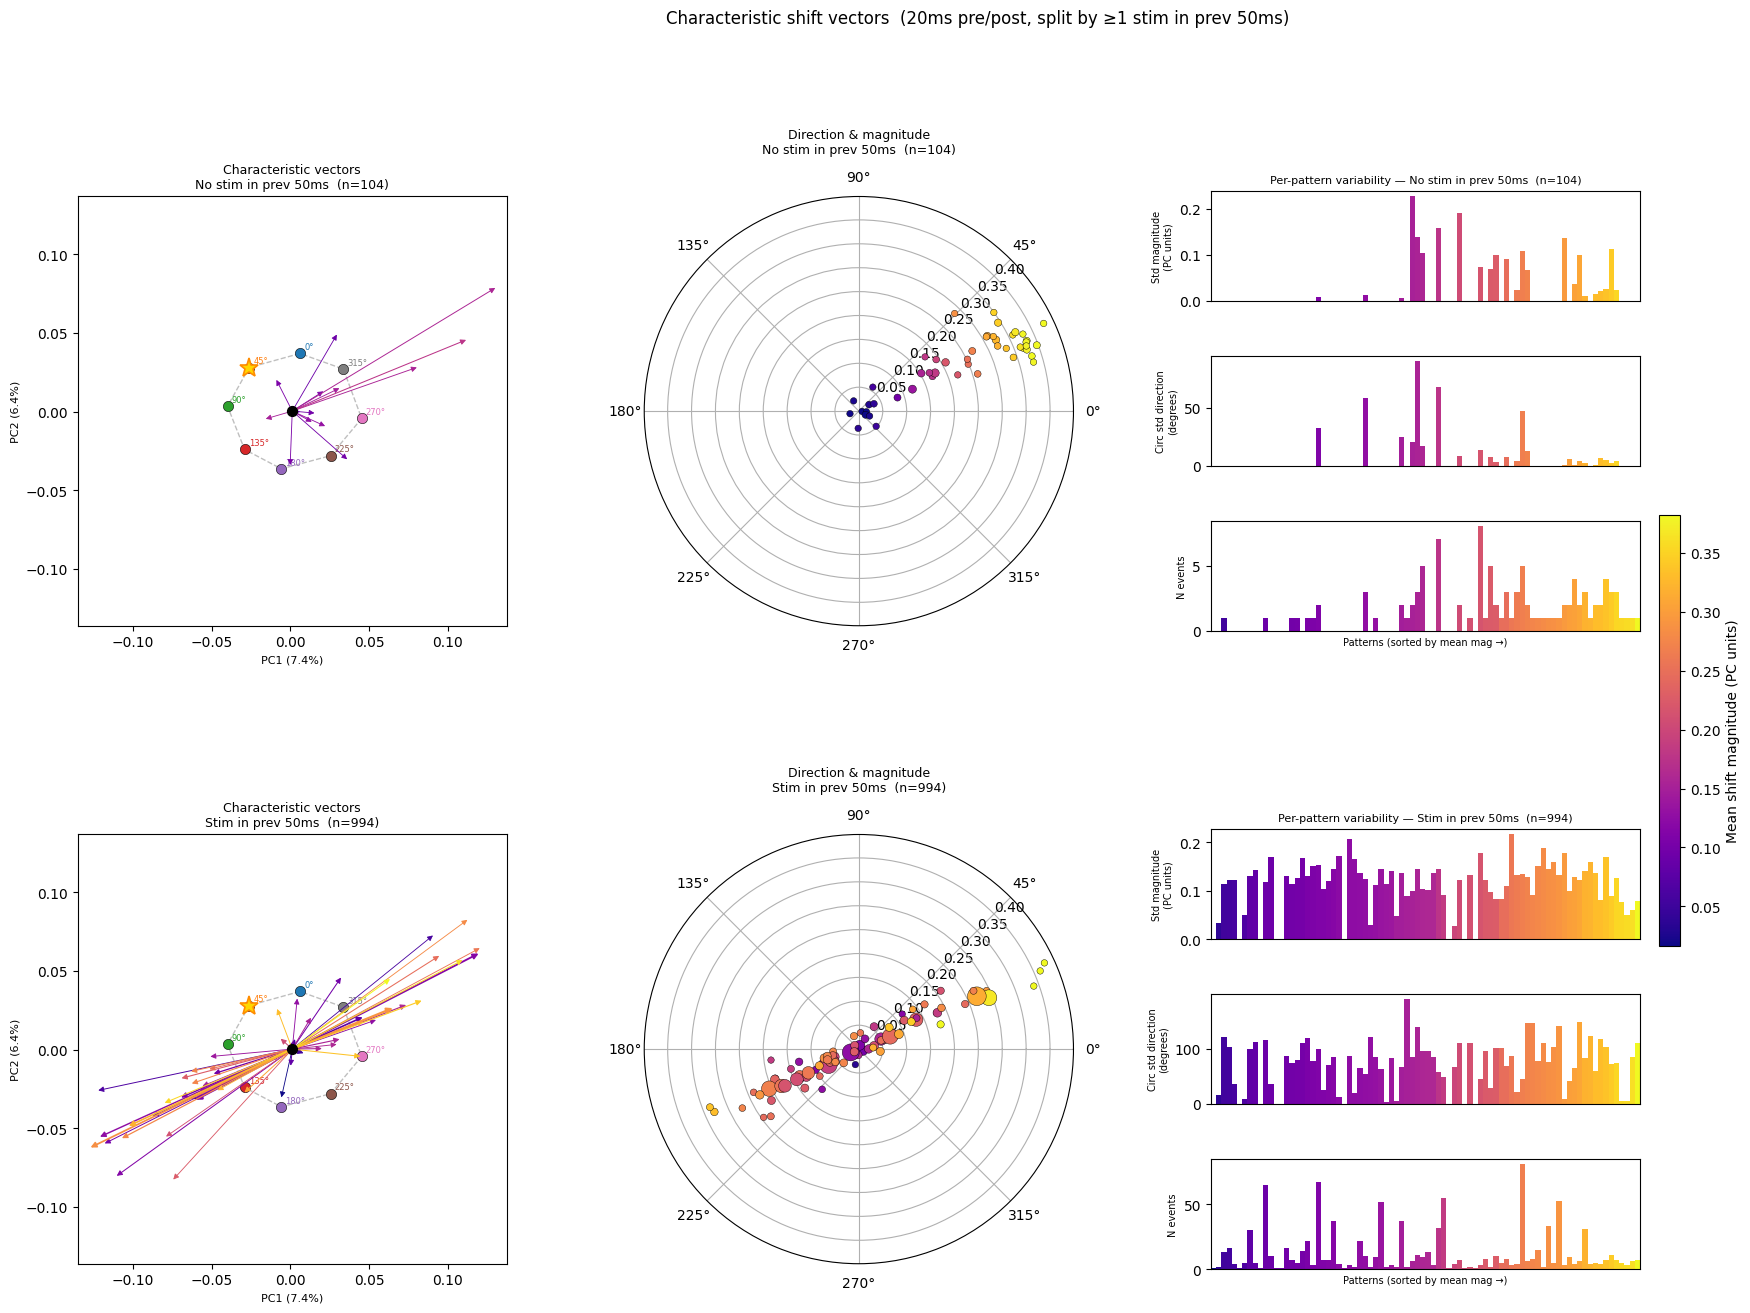

In [28]:
from collections import defaultdict
import matplotlib.gridspec as _gs

# ── Settings ──────────────────────────────────────────────────────────────
WIN_MS        = 20.0
WIN_BINS      = int(WIN_MS / bin_ms)      # 4 bins × 5ms = 20ms
PRECEDE_MS    = 50.0                      # look-back for "preceding stim" split

def _circ_std_deg(angles_rad):
    if len(angles_rad) < 2:
        return 0.0
    R = np.abs(np.exp(1j * np.array(angles_rad)).mean())
    return float(np.degrees(np.sqrt(-2.0 * np.log(np.clip(R, 1e-10, 1.0)))))

# ── All stim delivery times (for preceding-stim check) ────────────────────
all_stim_t = np.array([h["interval_start_ms"] for h in history
                        if h["delivered_pattern"] is not None])

# ── Collect per-instance vectors, split by preceding-stim condition ────────
_nb = flat_bins[:, :n_pca_neurons]

naive_vecs  = defaultdict(list)   # no stim in preceding 50ms
primed_vecs = defaultdict(list)   # stim in preceding 50ms

for h in history:
    if h["delivered_pattern"] is None:
        continue
    t_stim = h["interval_start_ms"]
    t_bin  = int(round(t_stim / bin_ms))
    pre_s, pre_e   = t_bin - WIN_BINS, t_bin
    post_s, post_e = t_bin,            t_bin + WIN_BINS
    if pre_s < 0 or post_e > len(_nb):
        continue

    pre_pc  = pca.transform(_nb[pre_s:pre_e,   :].mean(0)[None] / bin_ms)[0, :2]
    post_pc = pca.transform(_nb[post_s:post_e, :].mean(0)[None] / bin_ms)[0, :2]
    vec = post_pc - pre_pc

    fp = tuple(sorted(int(c) for c in h["delivered_pattern"]["channels"]))
    has_precede = np.any((all_stim_t >= t_stim - PRECEDE_MS) & (all_stim_t < t_stim))
    (primed_vecs if has_precede else naive_vecs)[fp].append(vec)

# ── Per-pattern stats for one condition ───────────────────────────────────
def _compute_char(vecs_dict):
    out = {}
    for fp, vecs in vecs_dict.items():
        V    = np.array(vecs)
        mags = np.linalg.norm(V, axis=1)
        dirs = np.arctan2(V[:, 1], V[:, 0])
        cv   = V.mean(0)
        out[fp] = {
            "vec":      cv,
            "mag":      float(np.linalg.norm(cv)),
            "dir":      float(np.arctan2(cv[1], cv[0])),
            "mean_mag": float(mags.mean()),
            "std_mag":  float(mags.std(ddof=1)) if len(vecs) > 1 else 0.0,
            "circ_std": _circ_std_deg(dirs),
            "n":        len(vecs),
        }
    return out

char_naive  = _compute_char(naive_vecs)
char_primed = _compute_char(primed_vecs)

# Sort by mean_mag pooling both conditions
all_fps = sorted(set(char_naive) | set(char_primed),
                 key=lambda k: (char_naive.get(k, {}).get("mean_mag", 0) +
                                char_primed.get(k, {}).get("mean_mag", 0)) / 2)
all_mean_mags = np.array([(char_naive.get(fp, {}).get("mean_mag", 0) +
                            char_primed.get(fp, {}).get("mean_mag", 0)) / 2
                           for fp in all_fps])
_norm = plt.Normalize(vmin=all_mean_mags.min(), vmax=all_mean_mags.max())
_cmap = plt.cm.plasma
_col  = lambda fp: _cmap(_norm((char_naive.get(fp, {}).get("mean_mag", 0) +
                                char_primed.get(fp, {}).get("mean_mag", 0)) / 2))

ring_cx = avg_pca[:, 0].mean()
ring_cy = avg_pca[:, 1].mean()

n_naive  = sum(v["n"] for v in char_naive.values())
n_primed = sum(v["n"] for v in char_primed.values())
print(f"Naive  (no stim in prev {PRECEDE_MS:.0f}ms): {len(char_naive)} patterns, {n_naive} events")
print(f"Primed (stim in prev {PRECEDE_MS:.0f}ms):    {len(char_primed)} patterns, {n_primed} events")

# ── Helpers ────────────────────────────────────────────────────────────────
def _draw_ring(ax):
    _ro = np.argsort(avg_angles)
    ax.plot(np.append(avg_pca[_ro, 0], avg_pca[_ro[0], 0]),
            np.append(avg_pca[_ro, 1], avg_pca[_ro[0], 1]),
            "--", color="grey", lw=1.0, alpha=0.5, zorder=1)
    for j, angle in enumerate(avg_angles):
        ax.scatter(avg_pca[j, 0], avg_pca[j, 1],
                   color=ori_colors[angle], s=55, edgecolors="k", lw=0.4, zorder=2)
        ax.annotate(f"{int(angle)}°", xy=(avg_pca[j, 0], avg_pca[j, 1]),
                    xytext=(3, 3), textcoords="offset points", fontsize=6, color=ori_colors[angle])
    ax.plot(target_pca[0], target_pca[1], "*", ms=14, color="gold", mec="darkorange", mew=1.2, zorder=3)
    ax.set_xlim(_xlim2); ax.set_ylim(_ylim2); ax.set_aspect("equal")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=8)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=8)

def _draw_arrows(ax, char_dict, fps):
    for fp in fps:
        if fp not in char_dict:
            continue
        dx, dy = char_dict[fp]["vec"]
        ax.annotate("", xy=(ring_cx + dx, ring_cy + dy), xytext=(ring_cx, ring_cy),
                    arrowprops=dict(arrowstyle="-|>", color=_col(fp),
                                    lw=0.6 + char_dict[fp]["n"] / 50, mutation_scale=8))
    ax.scatter(ring_cx, ring_cy, s=50, color="k", zorder=10)

def _draw_polar(ax, char_dict, fps):
    th = np.array([char_dict[fp]["dir"]      for fp in fps if fp in char_dict])
    r  = np.array([char_dict[fp]["mag"]      for fp in fps if fp in char_dict])
    mm = np.array([char_dict[fp]["mean_mag"] for fp in fps if fp in char_dict])
    sz = np.array([char_dict[fp]["n"]        for fp in fps if fp in char_dict])
    if len(th):
        sc = ax.scatter(th, r, c=mm, cmap=_cmap, norm=_norm,
                        s=20 + sz * 2, edgecolors="k", lw=0.3, zorder=3)
    ax.set_theta_zero_location("E"); ax.set_theta_direction(1); ax.set_rlabel_position(45)

def _draw_bars(ax_vmag, ax_vdir, ax_vn, char_dict, fps):
    x      = np.arange(len(fps))
    cols   = [_col(fp) for fp in fps]
    smags  = np.array([char_dict.get(fp, {}).get("std_mag",  0.0) for fp in fps])
    cdirs  = np.array([char_dict.get(fp, {}).get("circ_std", 0.0) for fp in fps])
    counts = np.array([char_dict.get(fp, {}).get("n",        0)   for fp in fps])

    ax_vmag.bar(x, smags,  color=cols, width=1.0, linewidth=0)
    ax_vdir.bar(x, cdirs,  color=cols, width=1.0, linewidth=0)
    ax_vn.bar(  x, counts, color=cols, width=1.0, linewidth=0)
    for ax in (ax_vmag, ax_vdir, ax_vn):
        ax.set_xlim(-0.5, len(fps) - 0.5); ax.set_xticks([])
    ax_vmag.set_ylabel("Std magnitude\n(PC units)", fontsize=7)
    ax_vdir.set_ylabel("Circ std direction\n(degrees)", fontsize=7)
    ax_vn.set_ylabel("N events", fontsize=7)
    ax_vn.set_xlabel("Patterns (sorted by mean mag →)", fontsize=7)

# ── Figure: 2 rows × 3 cols, right col has 3 nested subplots ─────────────
fig_cv = plt.figure(figsize=(24, 14))
outer  = _gs.GridSpec(2, 3, figure=fig_cv, wspace=0.32, hspace=0.45)

row_labels = [f"No stim in prev {PRECEDE_MS:.0f}ms  (n={n_naive})",
              f"Stim in prev {PRECEDE_MS:.0f}ms  (n={n_primed})"]
char_rows  = [char_naive, char_primed]

for row, (char_dict, row_lbl) in enumerate(zip(char_rows, row_labels)):
    fps_row = [fp for fp in all_fps if fp in char_dict]

    ax_ring = fig_cv.add_subplot(outer[row, 0])
    ax_pol  = fig_cv.add_subplot(outer[row, 1], projection="polar")
    inner   = _gs.GridSpecFromSubplotSpec(3, 1, subplot_spec=outer[row, 2], hspace=0.5)
    ax_vmag = fig_cv.add_subplot(inner[0])
    ax_vdir = fig_cv.add_subplot(inner[1])
    ax_vn   = fig_cv.add_subplot(inner[2])

    _draw_ring(ax_ring)
    _draw_arrows(ax_ring, char_dict, fps_row)
    ax_ring.set_title(f"Characteristic vectors\n{row_lbl}", fontsize=9)

    _draw_polar(ax_pol, char_dict, fps_row)
    ax_pol.set_title(f"Direction & magnitude\n{row_lbl}", fontsize=9, pad=12)

    _draw_bars(ax_vmag, ax_vdir, ax_vn, char_dict, all_fps)
    ax_vmag.set_title(f"Per-pattern variability — {row_lbl}", fontsize=8)

sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
sm.set_array([])
fig_cv.colorbar(sm, ax=fig_cv.axes, label="Mean shift magnitude (PC units)",
                shrink=0.4, pad=0.01, location="right")

plt.suptitle(f"Characteristic shift vectors  (20ms pre/post, split by ≥1 stim in prev {PRECEDE_MS:.0f}ms)",
             fontsize=12, y=1.01)
plt.savefig(os.path.join(DATA_DIR, "viz", "characteristic_vectors.png"), dpi=200, bbox_inches="tight")
plt.show()


## Cell 3 – PCA manifold: orientation reference + closed-loop trajectories

PCA is fit on the visual-orientation data so the orientation ring defines the basis.

**Data note:** `spike_rates.pkl` is non-zero only for the final 250 ms of the run because NEST's
ASCII backend overwrites `.dat` files on each `Simulate()` call.  Per-neuron population vectors
are therefore only available for the last interval.  Pre/post-stim trajectories are drawn only
where data exists; future runs that save per-interval spike vectors will populate all points.

A large ★ marks the **controller target**.  Opacity encodes experiment time (pale = early).


Explained variance (PC1–3): [0.074 0.064 0.052]
Rolling average: 6226 points  (window=70ms, step=5ms)
5 closest distances: [0.0071 0.0079 0.0081 0.0089 0.0092]


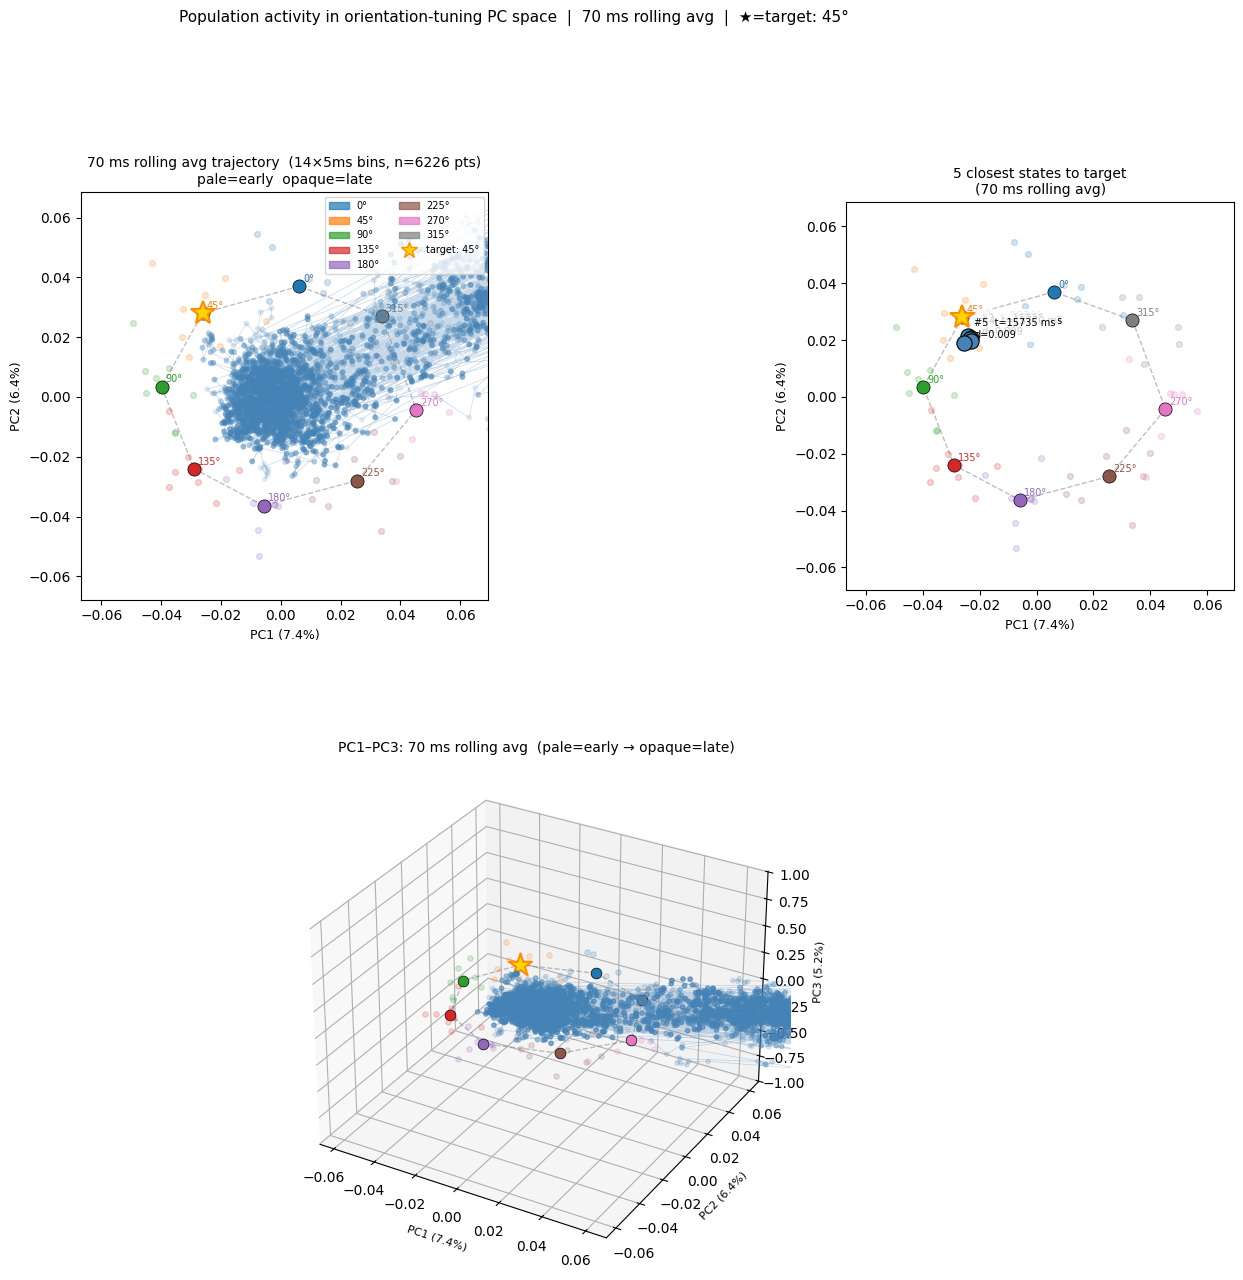

In [17]:
import matplotlib.gridspec as gridspec

# ── 1. Fit PCA on visual-orientation epoch vectors ─────────────────────────
with open(os.path.join(VIS_DIR, "visual8_spike_rates.pkl"), "rb") as f:
    vis_rates = pickle.load(f)
with open(os.path.join(VIS_DIR, "visual8_run_config.pkl"), "rb") as f:
    vis_config = pickle.load(f)

sample_info      = vis_config["sample_info"]
vis_centers_ms   = np.arange(vis_rates.shape[0]) * 100.0 + 250.0
orientations_deg = sorted(set(s[2] for s in sample_info))

epoch_vectors, epoch_angles = [], []
for start_ms, end_ms, angle_deg, _ in sample_info:
    mask = (vis_centers_ms >= start_ms) & (vis_centers_ms < end_ms)
    if mask.sum() == 0:
        continue
    epoch_vectors.append(vis_rates[mask].mean(axis=0))
    epoch_angles.append(angle_deg)
epoch_vectors = np.array(epoch_vectors)
epoch_angles  = np.array(epoch_angles)

avg_vectors = np.array([epoch_vectors[epoch_angles == a].mean(axis=0) for a in orientations_deg])
avg_angles  = np.array(orientations_deg)

pca = PCA(n_components=3)
pca.fit(epoch_vectors)
avg_pca   = pca.transform(avg_vectors)
epoch_pca = pca.transform(epoch_vectors)
n_pca_neurons = epoch_vectors.shape[1]
print(f"Explained variance (PC1-3): {pca.explained_variance_ratio_.round(3)}")

# ── 2. Target ──────────────────────────────────────────────────────────────
target_deg = config.get("target_orientation_deg", None)
if target_deg is not None and int(target_deg) in list(avg_angles):
    target_neural = avg_vectors[list(avg_angles).index(int(target_deg))]
    target_label  = f"target: {int(target_deg)}"
else:
    target_neural = np.zeros(n_pca_neurons, dtype=np.float32)
    target_label  = "target: silence"
target_pca = pca.transform(target_neural[None, :])[0]

# ── 2b. Probe vectors ─────────────────────────────────────────────────────
# max_vec[i]     = max firing rate neuron i achieved across all epoch windows
# mean_vec[i]    = mean firing rate of neuron i across all epochs (== pca.mean_)
# uniform_vec[i] = 1 for all i (scale-invariant: any constant gives same PC direction)
max_vec     = epoch_vectors.max(axis=0).astype(np.float32)
mean_vec    = epoch_vectors.mean(axis=0).astype(np.float32)
uniform_vec = np.ones(n_pca_neurons, dtype=np.float32)
max_pca     = pca.transform(max_vec[None,     :])[0]
mean_pca    = pca.transform(mean_vec[None,    :])[0]
uniform_pca = pca.transform(uniform_vec[None, :])[0]
print(f"Per-neuron max  -> PC1={max_pca[0]:.4f}  PC2={max_pca[1]:.4f}  PC3={max_pca[2]:.4f}")
print(f"Per-neuron mean -> PC1={mean_pca[0]:.4f}  PC2={mean_pca[1]:.4f}  PC3={mean_pca[2]:.4f}")
print(f"Uniform (all=1) -> PC1={uniform_pca[0]:.4f}  PC2={uniform_pca[1]:.4f}  PC3={uniform_pca[2]:.4f}")

# ── 3. 70ms rolling average from 5ms spike_bins ────────────────────────────
bins_path_npz = os.path.join(DATA_DIR, "closed_loop_spike_bins.npz")
d         = np.load(bins_path_npz)
bin_ms    = float(d["bin_ms"])
flat_bins = d["spike_bins"].reshape(-1, d["spike_bins"].shape[2]).astype(np.float32)
n_total_bins, n_neurons_bins = flat_bins.shape
bin_times_ms = np.arange(n_total_bins) * bin_ms

ROLL_W = 14   # 14 x 5ms = 70ms
fb   = flat_bins[:, :min(n_pca_neurons, n_neurons_bins)]
cs   = np.cumsum(fb, axis=0)
roll_counts = (cs[ROLL_W:] - cs[:-ROLL_W]) / ROLL_W
roll_rates  = roll_counts / bin_ms
roll_times  = bin_times_ms[ROLL_W:]
roll_pca    = pca.transform(roll_rates)
print(f"Rolling average: {roll_pca.shape[0]} points  (window={ROLL_W*bin_ms:.0f}ms, step={bin_ms:.0f}ms)")

# ── 4. 5 closest states to target ─────────────────────────────────────────
dists_roll  = np.linalg.norm(roll_pca[:, :2] - target_pca[:2], axis=1)
closest_idx = np.argsort(dists_roll)[:5]
closest_pca = roll_pca[closest_idx]
closest_times = roll_times[closest_idx]
closest_dists = dists_roll[closest_idx]
print(f"5 closest distances: {closest_dists.round(4)}")

# ── 5. Axis limits ─────────────────────────────────────────────────────────
cx, cy = avg_pca[:, 0].mean(), avg_pca[:, 1].mean()
half   = max(avg_pca[:, 0].max() - avg_pca[:, 0].min(),
             avg_pca[:, 1].max() - avg_pca[:, 1].min()) * 0.8
xlim   = (cx - half, cx + half)
ylim   = (cy - half, cy + half)
pad3   = max((avg_pca[:, 2].max() - avg_pca[:, 2].min()) * 0.6, 1.0)
zlim   = (avg_pca[:, 2].min() - pad3, avg_pca[:, 2].max() + pad3)

# ── 6. Plot (3D only) ──────────────────────────────────────────────────────
ori_cmap   = plt.cm.tab10
ori_colors = {a: ori_cmap(i / 10) for i, a in enumerate(sorted(orientations_deg))}
t_norm     = np.linspace(0, 1, roll_pca.shape[0])
pt_alphas  = 0.12 + 0.6 * t_norm

fig  = plt.figure(figsize=(10, 8))
ax3d = fig.add_subplot(111, projection="3d")

ring_order = np.argsort(avg_angles)
for j, angle in enumerate(avg_angles):
    m = epoch_angles == angle
    ax3d.scatter(epoch_pca[m,0], epoch_pca[m,1], epoch_pca[m,2],
                 color=ori_colors[angle], s=15, alpha=0.18, depthshade=False)
    ax3d.scatter(avg_pca[j,0], avg_pca[j,1], avg_pca[j,2],
                 color=ori_colors[angle], s=60, edgecolors="k", lw=0.5, depthshade=False)
    ax3d.text(avg_pca[j,0], avg_pca[j,1], avg_pca[j,2], f" {int(angle)}", fontsize=7,
              color=ori_colors[angle])
ax3d.plot(np.append(avg_pca[ring_order,0], avg_pca[ring_order[0],0]),
          np.append(avg_pca[ring_order,1], avg_pca[ring_order[0],1]),
          np.append(avg_pca[ring_order,2], avg_pca[ring_order[0],2]),
          "--", color="grey", lw=1.0, alpha=0.5)

rgba3d = np.zeros((len(roll_pca), 4))
rgba3d[:, :3] = np.array([0.27, 0.51, 0.71])
rgba3d[:, 3]  = pt_alphas
ax3d.scatter(roll_pca[:,0], roll_pca[:,1], roll_pca[:,2], c=rgba3d, s=10, depthshade=False)
ax3d.plot(roll_pca[:,0], roll_pca[:,1], roll_pca[:,2], color="steelblue", lw=0.5, alpha=0.3)

ax3d.scatter(*target_pca, marker="*", s=300, color="gold", edgecolors="darkorange",
             lw=1.5, depthshade=False, label=target_label)
ax3d.scatter(*max_pca,     marker="D", s=180, color="black",   edgecolors="white",
             lw=1.2, depthshade=False, label="per-neuron max")
ax3d.scatter(*mean_pca,    marker="s", s=180, color="dimgrey", edgecolors="white",
             lw=1.2, depthshade=False, label="per-neuron mean")
ax3d.scatter(*uniform_pca, marker="^", s=180, color="crimson", edgecolors="white",
             lw=1.2, depthshade=False, label="uniform (all=1, scale-invariant)")

ax3d.set_xlim(*xlim); ax3d.set_ylim(*ylim); ax3d.set_zlim(*zlim)
ax3d.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=8)
ax3d.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=8)
ax3d.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})", fontsize=8)
ax3d.set_title("PC1-PC3: 70 ms rolling avg  (pale=early, opaque=late)", fontsize=10)
ax3d.legend(fontsize=8)

plt.suptitle(
    f"Population activity in orientation-tuning PC space  |  70 ms rolling avg  |  *={target_label}",
    fontsize=11,
)
plt.savefig(os.path.join(DATA_DIR, "viz", "closed_loop_pca_rolling.png"), dpi=300, bbox_inches="tight")
plt.show()


Hz PCA var explained (PC1–2): [0.074 0.064]
Projected 3120 intervals. Median dist to target: 21.560
Rolling window: 200 intervals (2000 ms)


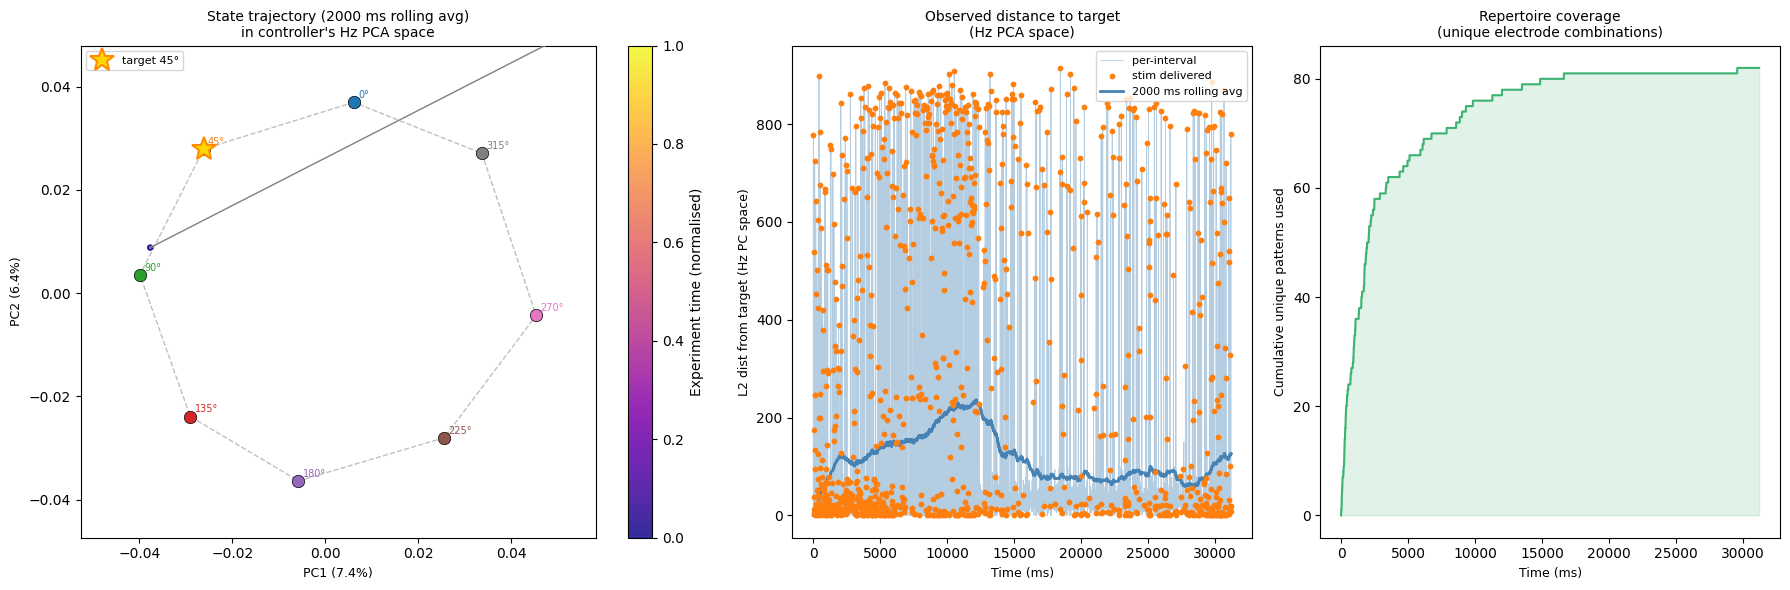

In [18]:
"""
Observed trajectory in the controller's 2-component PCA space (Hz firing rates).

Uses spike_counts_matrix (actual observed spikes) — no model forward passes.
The controller now works in raw Hz space; model predictions are exponentiated
to Hz before PC projection (see controller.py get_stim_pattern).
"""
from sklearn.decomposition import PCA as _PCA2

# ── 1. Fit 2-component PCA on visual epoch vectors in Hz (matches controller) ─
import torch as _torch
_meta  = _torch.load(os.path.join(config["model_dir"], "meta.pt"),
                     map_location="cpu", weights_only=False)
BIN_MS = float(_meta["bin_ms"])

with open(os.path.join(VIS_DIR, "visual8_spike_rates.pkl"), "rb") as f:
    _vr = pickle.load(f)
with open(os.path.join(VIS_DIR, "visual8_run_config.pkl"), "rb") as f:
    _vc = pickle.load(f)

_si, _vct = _vc["sample_info"], np.arange(_vr.shape[0]) * 100.0 + 250.0
_evecs, _eangs = [], []
for s_ms, e_ms, ang, _ in _si:
    m = (_vct >= s_ms) & (_vct < e_ms)
    if m.sum():
        _evecs.append(_vr[m].mean(0))
        _eangs.append(ang)
_evecs = np.array(_evecs, dtype=np.float32)   # Hz
_eangs = np.array(_eangs)

_pca2 = _PCA2(n_components=2)
_pca2.fit(_evecs)   # fit on raw Hz, no log transform
print(f"Hz PCA var explained (PC1–2): {_pca2.explained_variance_ratio_.round(3)}")

_ori_degs = sorted(set(s[2] for s in _si))
_avg_hz   = np.array([_evecs[_eangs == a].mean(0) for a in _ori_degs], dtype=np.float32)
_avg_pc2  = (_avg_hz - _pca2.mean_) @ _pca2.components_.T

_tgt_deg = config.get("target_orientation_deg")
if _tgt_deg is not None and int(_tgt_deg) in _ori_degs:
    _tgt_hz = _avg_hz[_ori_degs.index(int(_tgt_deg))]
else:
    _tgt_hz = np.zeros(_evecs.shape[1], dtype=np.float32)
_tgt_pc2 = (_tgt_hz - _pca2.mean_) @ _pca2.components_.T

# ── 2. Project observed spike_counts_matrix into Hz PCA space ─────────────
n_vis = _evecs.shape[1]
if spike_counts_matrix is not None:
    _obs_hz  = spike_counts_matrix[:, :n_vis].astype(np.float32) / (closed_loop_interval_ms / 1000.0)
    obs2_pca    = (_obs_hz - _pca2.mean_) @ _pca2.components_.T   # (n_intervals, 2)
    obs2_times  = np.array([h["interval_start_ms"] for h in history])
    obs2_stim   = np.array([h["delivered_pattern"] is not None for h in history])
    obs2_dist   = np.linalg.norm(obs2_pca - _tgt_pc2, axis=1)
    print(f"Projected {len(obs2_pca)} intervals. Median dist to target: {np.median(obs2_dist):.3f}")
else:
    print("WARNING: spike_counts_matrix not available.")
    obs2_pca, obs2_times, obs2_stim, obs2_dist = np.empty((0,2)), np.array([]), np.array([],bool), np.array([])

# ── 2b. Rolling averages (both 2000 ms) ───────────────────────────────────
def _rolling_mean(arr, win):
    """Causal rolling mean; output length == len(arr)."""
    k = np.ones(win) / win
    if arr.ndim == 1:
        return np.convolve(arr, k, mode='full')[:len(arr)]
    return np.column_stack([np.convolve(arr[:, c], k, mode='full')[:len(arr)] for c in range(arr.shape[1])])

if len(obs2_pca):
    _n_per_ms = 1.0 / closed_loop_interval_ms
    _w_2000   = max(1, round(2000.0 * _n_per_ms))   # 2000 ms for both
    roll_dist = _rolling_mean(obs2_dist, _w_2000)
    roll_pca  = _rolling_mean(obs2_pca,  _w_2000)
    print(f"Rolling window: {_w_2000} intervals (2000 ms)")
else:
    roll_dist = roll_pca = None

# ── 2c. Cumulative unique patterns (repertoire coverage) ──────────────────
_seen_patterns = set()
_cum_unique = []
for h in history:
    dp = h.get("delivered_pattern")
    if dp is not None:
        _seen_patterns.add(tuple(sorted(int(c) for c in dp["channels"])))
    _cum_unique.append(len(_seen_patterns))
cum_unique = np.array(_cum_unique)

# ── 3. Plot ──────────────────────────────────────────────────────────────
_ori_col = {a: plt.cm.tab10(i / 10) for i, a in enumerate(_ori_degs)}

fig, (ax_traj, ax_dist, ax_rep) = plt.subplots(1, 3, figsize=(18, 6),
                                                gridspec_kw={"width_ratios": [1.4, 1, 1]})

# ── trajectory (2000 ms rolling avg, clipped to ring extent) ─────────────
_ro = np.argsort(_ori_degs)
ax_traj.plot(np.append(_avg_pc2[_ro, 0], _avg_pc2[_ro[0], 0]),
             np.append(_avg_pc2[_ro, 1], _avg_pc2[_ro[0], 1]),
             "--", color="grey", lw=1.0, alpha=0.5)
for j, ang in enumerate(_ori_degs):
    ax_traj.scatter(_avg_pc2[j, 0], _avg_pc2[j, 1], color=_ori_col[ang],
                    s=80, edgecolors="k", lw=0.5, zorder=3)
    ax_traj.annotate(f"{int(ang)}°", (_avg_pc2[j, 0], _avg_pc2[j, 1]),
                     xytext=(3, 3), textcoords="offset points", fontsize=7, color=_ori_col[ang])

if roll_pca is not None:
    norm_t = (obs2_times - obs2_times[0]) / max(obs2_times[-1] - obs2_times[0], 1)
    sc = ax_traj.scatter(roll_pca[:, 0], roll_pca[:, 1],
                         c=norm_t, cmap="plasma", s=14, zorder=5, alpha=0.85)
    ax_traj.plot(roll_pca[:, 0], roll_pca[:, 1], lw=1.5, color="white", zorder=6, alpha=0.7)
    ax_traj.plot(roll_pca[:, 0], roll_pca[:, 1], lw=1.0, color="black", zorder=7, alpha=0.5)
    plt.colorbar(sc, ax=ax_traj, label="Experiment time (normalised)")

ax_traj.plot(_tgt_pc2[0], _tgt_pc2[1], "*", ms=18, color="gold",
             mec="darkorange", mew=1.5, zorder=10, label=f"target {_tgt_deg}°")

# Constrain axes to ring extent + small margin
_pad = 0.15
_ring_x1, _ring_x2 = _avg_pc2[:, 0].min(), _avg_pc2[:, 0].max()
_ring_y1, _ring_y2 = _avg_pc2[:, 1].min(), _avg_pc2[:, 1].max()
_rx = (_ring_x2 - _ring_x1) * _pad
_ry = (_ring_y2 - _ring_y1) * _pad
ax_traj.set_xlim(_ring_x1 - _rx, _ring_x2 + _rx)
ax_traj.set_ylim(_ring_y1 - _ry, _ring_y2 + _ry)

ax_traj.set_xlabel(f"PC1 ({_pca2.explained_variance_ratio_[0]:.1%})", fontsize=9)
ax_traj.set_ylabel(f"PC2 ({_pca2.explained_variance_ratio_[1]:.1%})", fontsize=9)
ax_traj.set_title(f"State trajectory (2000 ms rolling avg)\nin controller's Hz PCA space", fontsize=10)
ax_traj.legend(fontsize=8)

# ── distance over time ────────────────────────────────────────────────────
if len(obs2_dist):
    ax_dist.plot(obs2_times, obs2_dist, color="steelblue", lw=0.6, alpha=0.4, label="per-interval")
    ax_dist.scatter(obs2_times[obs2_stim], obs2_dist[obs2_stim],
                    color="tab:orange", s=10, zorder=4, label="stim delivered")
    if roll_dist is not None:
        ax_dist.plot(obs2_times, roll_dist, color="steelblue", lw=2.0,
                     label="2000 ms rolling avg")
ax_dist.set_xlabel("Time (ms)", fontsize=9)
ax_dist.set_ylabel("L2 dist from target (Hz PC space)", fontsize=9)
ax_dist.set_title("Observed distance to target\n(Hz PCA space)", fontsize=10)
ax_dist.legend(fontsize=8)

# ── repertoire coverage ───────────────────────────────────────────────────
if len(obs2_times):
    ax_rep.plot(obs2_times, cum_unique, color="mediumseagreen", lw=1.5)
    ax_rep.fill_between(obs2_times, cum_unique, alpha=0.15, color="mediumseagreen")
ax_rep.set_xlabel("Time (ms)", fontsize=9)
ax_rep.set_ylabel("Cumulative unique patterns used", fontsize=9)
ax_rep.set_title("Repertoire coverage\n(unique electrode combinations)", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "viz", "controller_observed_trajectory.png"), dpi=200, bbox_inches="tight")
plt.show()


Explained variance (PC1-3): [0.074 0.064 0.052]
Per-neuron max  -> PC1=0.0297  PC2=0.0133  PC3=0.0009
Per-neuron mean -> PC1=0.0000  PC2=0.0000  PC3=-0.0000
Uniform (all=1) -> PC1=0.0211  PC2=0.0073  PC3=0.0087
Rolling average: 6 points  (window=70ms, step=5ms)
5 closest distances: [0.1376 0.1376 0.1376 0.1394 0.1703]


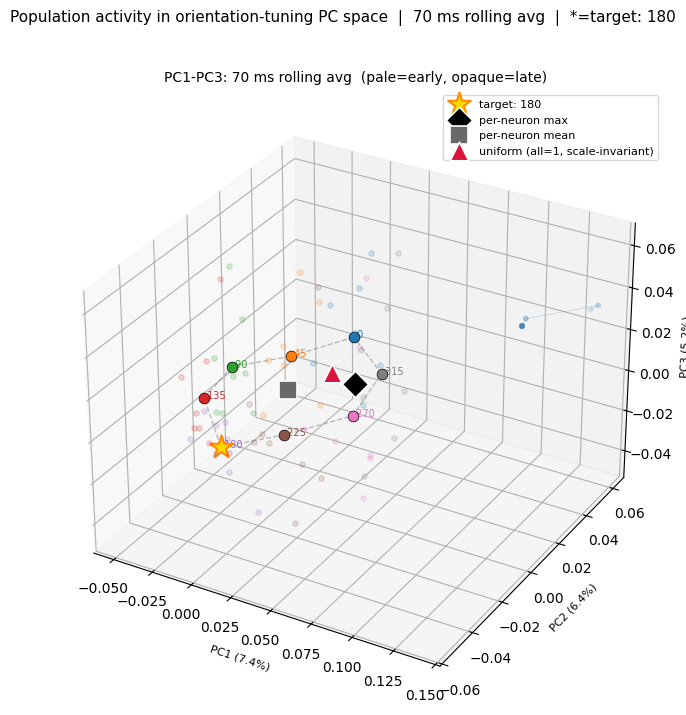

In [ ]:
# ── 1. Fit PCA on visual-orientation epoch vectors ─────────────────────────
with open(os.path.join(VIS_DIR, "visual8_spike_rates.pkl"), "rb") as f:
    vis_rates = pickle.load(f)
with open(os.path.join(VIS_DIR, "visual8_run_config.pkl"), "rb") as f:
    vis_config = pickle.load(f)

sample_info      = vis_config["sample_info"]
vis_centers_ms   = np.arange(vis_rates.shape[0]) * 100.0 + 250.0
orientations_deg = sorted(set(s[2] for s in sample_info))

epoch_vectors, epoch_angles = [], []
for start_ms, end_ms, angle_deg, _ in sample_info:
    mask = (vis_centers_ms >= start_ms) & (vis_centers_ms < end_ms)
    if mask.sum() == 0:
        continue
    epoch_vectors.append(vis_rates[mask].mean(axis=0))
    epoch_angles.append(angle_deg)
epoch_vectors = np.array(epoch_vectors)
epoch_angles  = np.array(epoch_angles)

avg_vectors = np.array([epoch_vectors[epoch_angles == a].mean(axis=0) for a in orientations_deg])
avg_angles  = np.array(orientations_deg)

pca = PCA(n_components=3)
pca.fit(epoch_vectors)
avg_pca   = pca.transform(avg_vectors)
epoch_pca = pca.transform(epoch_vectors)
n_pca_neurons = epoch_vectors.shape[1]
print(f"Explained variance (PC1-3): {pca.explained_variance_ratio_.round(3)}")

# ── 2. Target ──────────────────────────────────────────────────────────────
target_deg = config.get("target_orientation_deg", None)
if target_deg is not None and int(target_deg) in list(avg_angles):
    target_neural = avg_vectors[list(avg_angles).index(int(target_deg))]
    target_label  = f"target: {int(target_deg)}"
else:
    target_neural = np.zeros(n_pca_neurons, dtype=np.float32)
    target_label  = "target: silence"
target_pca = pca.transform(target_neural[None, :])[0]

# ── 2b. Probe vectors ─────────────────────────────────────────────────────
# max_vec[i]     = max firing rate neuron i achieved across all epoch windows
# mean_vec[i]    = mean firing rate of neuron i across all epochs (== pca.mean_)
# uniform_vec[i] = 1 for all i (scale-invariant: any constant gives same PC direction)
max_vec     = epoch_vectors.max(axis=0).astype(np.float32)
mean_vec    = epoch_vectors.mean(axis=0).astype(np.float32)
uniform_vec = np.ones(n_pca_neurons, dtype=np.float32) * 0.01
max_pca     = pca.transform(max_vec[None,     :])[0]
mean_pca    = pca.transform(mean_vec[None,    :])[0]
uniform_pca = pca.transform(uniform_vec[None, :])[0]
print(f"Per-neuron max  -> PC1={max_pca[0]:.4f}  PC2={max_pca[1]:.4f}  PC3={max_pca[2]:.4f}")
print(f"Per-neuron mean -> PC1={mean_pca[0]:.4f}  PC2={mean_pca[1]:.4f}  PC3={mean_pca[2]:.4f}")
print(f"Uniform (all=1) -> PC1={uniform_pca[0]:.4f}  PC2={uniform_pca[1]:.4f}  PC3={uniform_pca[2]:.4f}")


# ── 5. Axis limits ─────────────────────────────────────────────────────────
cx, cy = avg_pca[:, 0].mean(), avg_pca[:, 1].mean()
half   = max(avg_pca[:, 0].max() - avg_pca[:, 0].min(),
             avg_pca[:, 1].max() - avg_pca[:, 1].min()) * 0.8
xlim   = (cx - half, cx + half)
ylim   = (cy - half, cy + half)
pad3   = max((avg_pca[:, 2].max() - avg_pca[:, 2].min()) * 0.6, 1.0)
zlim   = (avg_pca[:, 2].min() - pad3, avg_pca[:, 2].max() + pad3)

# ── 6. Plot (3D only) ──────────────────────────────────────────────────────
ori_cmap   = plt.cm.tab10
ori_colors = {a: ori_cmap(i / 10) for i, a in enumerate(sorted(orientations_deg))}
t_norm     = np.linspace(0, 1, roll_pca.shape[0])
pt_alphas  = 0.12 + 0.6 * t_norm

fig  = plt.figure(figsize=(10, 8))
ax3d = fig.add_subplot(111, projection="3d")

ring_order = np.argsort(avg_angles)
for j, angle in enumerate(avg_angles):
    m = epoch_angles == angle
    ax3d.scatter(epoch_pca[m,0], epoch_pca[m,1], epoch_pca[m,2],
                 color=ori_colors[angle], s=15, alpha=0.18, depthshade=False)
    ax3d.scatter(avg_pca[j,0], avg_pca[j,1], avg_pca[j,2],
                 color=ori_colors[angle], s=60, edgecolors="k", lw=0.5, depthshade=False)
    ax3d.text(avg_pca[j,0], avg_pca[j,1], avg_pca[j,2], f" {int(angle)}", fontsize=7,
              color=ori_colors[angle])
ax3d.plot(np.append(avg_pca[ring_order,0], avg_pca[ring_order[0],0]),
          np.append(avg_pca[ring_order,1], avg_pca[ring_order[0],1]),
          np.append(avg_pca[ring_order,2], avg_pca[ring_order[0],2]),
          "--", color="grey", lw=1.0, alpha=0.5)

rgba3d = np.zeros((len(roll_pca), 4))
rgba3d[:, :3] = np.array([0.27, 0.51, 0.71])
rgba3d[:, 3]  = pt_alphas
ax3d.scatter(roll_pca[:,0], roll_pca[:,1], roll_pca[:,2], c=rgba3d, s=10, depthshade=False)
ax3d.plot(roll_pca[:,0], roll_pca[:,1], roll_pca[:,2], color="steelblue", lw=0.5, alpha=0.3)

ax3d.scatter(*target_pca, marker="*", s=300, color="gold", edgecolors="darkorange",
             lw=1.5, depthshade=False, label=target_label)
ax3d.scatter(*max_pca,     marker="D", s=180, color="black",   edgecolors="white",
             lw=1.2, depthshade=False, label="per-neuron max")
ax3d.scatter(*mean_pca,    marker="s", s=180, color="dimgrey", edgecolors="white",
             lw=1.2, depthshade=False, label="per-neuron mean")
ax3d.scatter(*uniform_pca, marker="^", s=180, color="crimson", edgecolors="white",
             lw=1.2, depthshade=False, label="uniform (all=1, scale-invariant)")

# ax3d.set_xlim(*xlim); ax3d.set_ylim(*ylim); ax3d.set_zlim(*zlim)
ax3d.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=8)
ax3d.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=8)
ax3d.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})", fontsize=8)
ax3d.set_title("PC1-PC3: 70 ms rolling avg  (pale=early, opaque=late)", fontsize=10)
ax3d.legend(fontsize=8)

plt.suptitle(
    f"Population   |  70 ms rolling avg  |  *={target_label}",
    fontsize=11,
)
plt.savefig(os.path.join(DATA_DIR, "viz", "closed_loop_pca_rolling.png"), dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
"""
Sanity check: AR-predicted vs true NEST-simulated state for single-pulse stimulation.

Patterns: N_ELECTRODES x len(STIM_AMPS_UA) single-pulse patterns + 1 no-stim.
NEST is initialized ONCE. Controller spike_buf is reset to the post-burn-in snapshot
before every AR prediction so all predictions start from the same state.
A washout period separates each true NEST simulation.
"""

import logging, sys, time
import torch as _torch
from system import SystemNESTSim
from controller import RepertoireController
from models import StimEncodingCNN
import nest as _nest

# ── Parameters ────────────────────────────────────────────────────────────
BURN_IN_MS     = 1000.0          # initial no-stim warm-up
WASHOUT_MS     = 200.0            # no-stim between patterns
K_PRED_BINS    = 14               # AR horizon = true simulation window (bins)
AR_AGGREGATION = "average"        # "most_recent" or "average"
STIM_AMPS_UA   = [3, 4, 5, 6] # list of amplitudes to probe (µA)
STIM_TIME_MS   = 0.0              # pulse time within interval
N_ELECTRODES   = 32
OUTPUT_NAME    = "sanity_check_sim"

# ── Logging: both notebook stdout and file ────────────────────────────────
_log_path = os.path.join(DATA_DIR, "viz", "sanity_check.log")
os.makedirs(os.path.join(DATA_DIR, "viz"), exist_ok=True)

_logger = logging.getLogger("sanity_check")
_logger.setLevel(logging.DEBUG)
_logger.handlers.clear()
_fh = logging.FileHandler(_log_path, mode="w")
_fh.setFormatter(logging.Formatter("%(asctime)s  %(message)s", datefmt="%H:%M:%S"))
_sh = logging.StreamHandler(sys.stdout)
_sh.setFormatter(logging.Formatter("%(message)s"))
_logger.addHandler(_fh)
_logger.addHandler(_sh)

_logger.info(f"Log file: {_log_path}")

# ── Load model ────────────────────────────────────────────────────────────
device = _torch.device("mps" if _torch.backends.mps.is_available() else "cpu")
_meta = _torch.load(os.path.join(config["model_dir"], "meta.pt"),
                    map_location=device, weights_only=False)
_model = StimEncodingCNN(
    n_stim_channels=_meta["n_stim_channels"],
    n_neurons=_meta["n_neurons"],
    n_input_bins=_meta["n_input_bins"],
    n_output_bins=_meta["n_output_bins"],
    conv_channels=_meta.get("conv_channels", [256, 256]),
    kernel_sizes=_meta.get("kernel_sizes", [3, 3]),
    fc_dims=_meta.get("fc_dims", [256]),
    history=_meta.get("history", 1),
    use_init_state=_meta.get("use_init_state", True),
).to(device)
_model.load_state_dict(_torch.load(
    os.path.join(config["model_dir"], "model.pt"), map_location=device, weights_only=True
))
_model.eval()
_logger.info(f"Model loaded on {device}")

_bin_ms      = float(_meta["bin_ms"])
_interval_ms = _bin_ms * K_PRED_BINS
_n_model     = _meta["n_neurons"]

# ── PCA (reuses epoch_vectors / pca / avg_pca / avg_angles from cell-pca) ─
_n_vis    = epoch_vectors.shape[1]
_pca_comp = pca.components_.astype(np.float32)
_pca_mean = pca.mean_.astype(np.float32)

if _n_vis < _n_model:
    _pca_comp_m = np.concatenate([_pca_comp, np.zeros((2, _n_model-_n_vis), dtype=np.float32)], axis=1)
    _pca_mean_m = np.concatenate([_pca_mean, np.zeros(_n_model-_n_vis, dtype=np.float32)])
else:
    _pca_comp_m = _pca_comp[:, :_n_model]
    _pca_mean_m = _pca_mean[:_n_model]

_target_deg = config.get("target_orientation_deg")
_target_m   = np.zeros(_n_model, dtype=np.float32)
if _target_deg is not None and int(_target_deg) in list(avg_angles):
    _tv = avg_vectors[list(avg_angles).index(int(_target_deg))].astype(np.float32)
    _target_m[:min(_n_vis, _n_model)] = _tv[:min(_n_vis, _n_model)]

# ── Build patterns: all (electrode, amp) combos + no-stim ────────────────
_patterns = [
    {"channels": np.array([ch]), "times_ms": np.array([STIM_TIME_MS]),
     "amplitudes_uA": np.array([amp])}
    for amp in STIM_AMPS_UA
    for ch in range(N_ELECTRODES)
]
_patterns.append(None)
_labels = [f"ch{ch}@{amp}uA" for amp in STIM_AMPS_UA for ch in range(N_ELECTRODES)] + ["no-stim"]
_logger.info(f"{len(_patterns)} patterns  ({N_ELECTRODES} electrodes x {len(STIM_AMPS_UA)} amps + 1 no-stim)")
_logger.info(f"K_PRED_BINS={K_PRED_BINS}  window={_interval_ms:.0f} ms  "
             f"washout={WASHOUT_MS:.0f} ms  ar_aggregation={AR_AGGREGATION!r}")

# ── Initialize NEST once ──────────────────────────────────────────────────
_t0 = time.time()
_logger.info("Initializing NEST...")
sim = SystemNESTSim(output_name=OUTPUT_NAME, fast_mode=True)
_logger.info(f"  NEST init done in {time.time()-_t0:.1f}s")

_logger.info(f"  Burn-in {BURN_IN_MS:.0f} ms ...")
_t0 = time.time()
_nest.Simulate(BURN_IN_MS)
_bio_t_snap    = SystemNESTSim.get_current_biological_time_ms()
_spike_trains0 = sim.network.get_spike_train_list()
_logger.info(f"  Burn-in done in {time.time()-_t0:.1f}s  (t={_bio_t_snap:.0f} ms)")

# Build reference controller + snapshot spike_buf
_ctrl_ref = RepertoireController(
    model=_model, meta=_meta,
    target=_target_m,
    pca_components=_pca_comp_m,
    pca_mean=_pca_mean_m,
    n_relevant_output_bins=K_PRED_BINS,
    ar_aggregation=AR_AGGREGATION,
    device=str(device),
)
_n_total   = _ctrl_ref.n_total_bins
_buf_t0    = _bio_t_snap - _n_total * _bin_ms
_bin_edges = np.arange(_n_total + 1) * _bin_ms + _buf_t0

_logger.info(f"  Building spike_buf ({len(_spike_trains0)} neurons x {_n_total} bins)...")
_t0 = time.time()
for ni, train in enumerate(_spike_trains0):
    train = np.asarray(train)
    if len(train):
        _ctrl_ref.spike_buf[ni] = np.histogram(train, bins=_bin_edges)[0].astype(np.float32)
_ctrl_ref.stim_buf[:] = 0.0
_logger.info(f"  spike_buf built in {time.time()-_t0:.1f}s")

_spike_buf_snap = _ctrl_ref.spike_buf.copy()
_stim_buf_snap  = _ctrl_ref.stim_buf.copy()

# ── Per-pattern loop ──────────────────────────────────────────────────────
pred_pcs = []
true_pcs = []
_tgt2    = _ctrl_ref._target_pc[:2]

for pi, pat in enumerate(_patterns):
    label = _labels[pi]
    _t0 = time.time()

    # Reset controller to snapshot
    _ctrl_ref.spike_buf = _spike_buf_snap.copy()
    _ctrl_ref.stim_buf  = _stim_buf_snap.copy()

    # Predicted: AR forward from snapshotted state
    _stim_bins = _ctrl_ref._stim_dict_to_bins(pat)
    _inp       = _ctrl_ref._build_model_input(_stim_bins)[None].copy()
    _all_ar    = _ctrl_ref._ar_forward(_inp)              # (1, K_PRED_BINS, n_neurons)
    _pred_log  = _ctrl_ref._process_ar_preds(_all_ar)[0]  # (n_neurons,)
    _pred_hz   = np.exp(_pred_log) / _bin_ms * 1000.0
    _pred_pc   = (_pred_hz[:_n_vis] - _pca_mean) @ _pca_comp.T
    pred_pcs.append(_pred_pc)

    # True: deliver stim, simulate, measure average Hz
    _bio_t_before = SystemNESTSim.get_current_biological_time_ms()
    if pat is not None:
        _chs  = np.asarray(pat["channels"],      dtype=int)
        _tms  = np.asarray(pat["times_ms"],      dtype=float)
        _amps = np.asarray(pat["amplitudes_uA"], dtype=float)
        _in_win = _tms < _interval_ms
        _chs, _tms, _amps = _chs[_in_win], _tms[_in_win], _amps[_in_win]
        if len(_chs) > 0:
            _gens = sim.create_generators_from_channel_events(
                _chs, _bio_t_before + _tms, _amps)
            sim.network.simulate_current_input(_gens, time_ms=float(_interval_ms))
        else:
            _nest.Simulate(float(_interval_ms))
    else:
        _nest.Simulate(float(_interval_ms))

    _trains_after = sim.network.get_spike_train_list()
    _true_hz = np.zeros(_n_vis, dtype=np.float32)
    for ni in range(min(_n_vis, len(_trains_after))):
        train = np.asarray(_trains_after[ni])
        cnt = np.sum((train >= _bio_t_before) & (train < _bio_t_before + _interval_ms))
        _true_hz[ni] = float(cnt) / (_interval_ms / 1000.0)
    _true_pc = (_true_hz - _pca_mean) @ _pca_comp.T
    true_pcs.append(_true_pc)

    _logger.info(
        f"[{pi+1:3d}/{len(_patterns)}] {label:18s}  "
        f"pred_dist={np.linalg.norm(_pred_pc - _tgt2):.3f}  "
        f"true_dist={np.linalg.norm(_true_pc - _tgt2):.3f}  "
        f"({time.time()-_t0:.1f}s)"
    )

    if pi < len(_patterns) - 1:
        _t0 = time.time()
        _nest.Simulate(WASHOUT_MS)
        _logger.info(f"  washout done in {time.time()-_t0:.1f}s")

pred_pcs = np.array(pred_pcs)
true_pcs = np.array(true_pcs)
_logger.info("All patterns done. Plotting...")

# ── Plot: one subplot per amplitude + no-stim on all ─────────────────────
_n_amps  = len(STIM_AMPS_UA)
_amp_colors = plt.cm.viridis(np.linspace(0.2, 0.9, _n_amps))

fig, axes = plt.subplots(1, _n_amps, figsize=(7 * _n_amps, 7), squeeze=False)
axes = axes[0]

_cx, _cy = avg_pca[:, 0].mean(), avg_pca[:, 1].mean()
_half = max(avg_pca[:, 0].max() - avg_pca[:, 0].min(),
            avg_pca[:, 1].max() - avg_pca[:, 1].min()) * 0.8
_ro = np.argsort(avg_angles)

for ai, (amp, ax) in enumerate(zip(STIM_AMPS_UA, axes)):
    # ring
    ax.plot(np.append(avg_pca[_ro, 0], avg_pca[_ro[0], 0]),
            np.append(avg_pca[_ro, 1], avg_pca[_ro[0], 1]),
            "--", color="grey", lw=1.2, alpha=0.6, zorder=1)
    for j, angle in enumerate(avg_angles):
        ax.scatter(avg_pca[j, 0], avg_pca[j, 1],
                   color=ori_colors[angle], s=80, edgecolors="k", lw=0.5, zorder=3)
        ax.annotate(f"{int(angle)}", xy=(avg_pca[j, 0], avg_pca[j, 1]),
                    xytext=(3, 3), textcoords="offset points", fontsize=7, color=ori_colors[angle])
    ax.plot(_tgt2[0], _tgt2[1], "*", ms=18, color="gold",
            mec="darkorange", mew=1.5, zorder=10, label=f"target ({_target_deg}°)")

    # electrode patterns for this amp
    _sl = slice(ai * N_ELECTRODES, (ai + 1) * N_ELECTRODES)
    for i in range(N_ELECTRODES):
        idx = ai * N_ELECTRODES + i
        ax.plot([pred_pcs[idx, 0], true_pcs[idx, 0]],
                [pred_pcs[idx, 1], true_pcs[idx, 1]],
                color="grey", lw=0.7, alpha=0.4, zorder=4)
    ax.scatter(pred_pcs[_sl, 0], pred_pcs[_sl, 1], color="steelblue", s=55,
               edgecolors="k", lw=0.5, zorder=6, label="predicted")
    ax.scatter(true_pcs[_sl, 0],  true_pcs[_sl, 1],  color="crimson", s=55,
               edgecolors="k", lw=0.5, zorder=6, label="true")

    # no-stim (last entry) on every panel
    ax.plot([pred_pcs[-1, 0], true_pcs[-1, 0]],
            [pred_pcs[-1, 1], true_pcs[-1, 1]],
            color="grey", lw=0.7, alpha=0.4, zorder=4)
    ax.scatter(pred_pcs[-1, 0], pred_pcs[-1, 1], color="steelblue", s=130,
               marker="s", edgecolors="k", lw=1.0, zorder=7, label="predicted (no-stim)")
    ax.scatter(true_pcs[-1, 0],  true_pcs[-1, 1],  color="crimson", s=130,
               marker="s", edgecolors="k", lw=1.0, zorder=7, label="true (no-stim)")

    ax.set_xlim(_cx - _half, _cx + _half)
    ax.set_ylim(_cy - _half, _cy + _half)
    ax.set_aspect("equal")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=9)
    ax.legend(fontsize=7)
    ax.set_title(
        f"amp = {amp} µA\n"
        f"K_PRED_BINS={K_PRED_BINS}  window={_interval_ms:.0f} ms  {AR_AGGREGATION}",
        fontsize=9,
    )

plt.suptitle(
    f"Single-pulse sanity check: predicted (blue) vs true (red)\n"
    f"washout={WASHOUT_MS:.0f} ms  |  log → {_log_path}",
    fontsize=10,
)
plt.tight_layout()
_fig_path = os.path.join(DATA_DIR, "viz", "sanity_check_pred_vs_true.png")
plt.savefig(_fig_path, dpi=200, bbox_inches="tight")
_logger.info(f"Figure saved to {_fig_path}")
plt.show()


Log file: outputs/data_system_sim_0.05scale/closed_loop_orientation180_10msinterval_learning_180/viz/sanity_check.log
Model loaded on mps
129 patterns  (32 electrodes x 4 amps + 1 no-stim)
K_PRED_BINS=10  window=50 ms  washout=500 ms  ar_aggregation='average'
Initializing NEST...
Data will be written to: /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/sanity_check_sim
  Directory already existed. Old data will be overwritten.

Neuron numbers are scaled by a factor of 0.050.
Indegrees are scaled by a factor of 0.050.
  Weights and DC input are adjusted to compensate.

RNG seed: 42
Total number of virtual processes: 4
Creating neuronal populations.
Creating recording devices.
  Creating spike recorders.
Creating Poisson generators for background input.
Connecting neuronal populations recurrently.
Connecting Poisson generators for background input.
Simulating 1000 ms.
SystemNESTSim initialized.
Total # neurons simulated: 3858
Data path: /Users/shubhom/

TypeError: RepertoireController._process_ar_preds() missing 1 required positional argument: 'bin_ms'

In [ ]:
#
 
─
─
 
P
e
r
-
e
l
e
c
t
r
o
d
e
 
P
C
-
s
p
a
c
e
 
s
h
i
f
t
 
a
n
a
l
y
s
i
s
 
(
N
o
E
n
c
o
d
e
r
C
o
n
t
r
o
l
l
e
r
 
m
u
l
t
i
-
t
r
i
a
l
)
 
─
─
─
─

#

#
 
F
o
r
 
e
a
c
h
 
i
n
t
e
r
v
a
l
 
i
 
w
h
e
r
e
 
a
 
s
i
n
g
l
e
-
e
l
e
c
t
r
o
d
e
 
s
t
i
m
 
w
a
s
 
d
e
l
i
v
e
r
e
d
:

#
 
 
 
p
r
e
 
 
=
 
m
e
a
n
 
s
p
i
k
e
 
r
a
t
e
 
o
v
e
r
 
i
n
t
e
r
v
a
l
 
i
-
1
 
(
p
r
e
-
s
t
i
m
 
b
a
s
e
l
i
n
e
)

#
 
 
 
p
o
s
t
 
=
 
m
e
a
n
 
s
p
i
k
e
 
r
a
t
e
 
o
v
e
r
 
i
n
t
e
r
v
a
l
 
i
 
 
 
(
r
e
s
p
o
n
s
e
 
w
i
n
d
o
w
)

#
 
 
 
s
h
i
f
t
 
=
 
p
c
a
.
t
r
a
n
s
f
o
r
m
(
p
o
s
t
)
 
-
 
p
c
a
.
t
r
a
n
s
f
o
r
m
(
p
r
e
)

#

#
 
A
r
r
o
w
s
 
s
h
o
w
 
t
h
e
 
m
e
a
n
 
s
h
i
f
t
 
v
e
c
t
o
r
 
p
e
r
 
e
l
e
c
t
r
o
d
e
,
 
a
v
e
r
a
g
e
d
 
a
c
r
o
s
s
 
a
l
l
 
t
r
i
a
l
s
.

#
 
S
i
l
v
e
r
 
d
o
t
 
=
 
m
e
a
n
 
s
h
i
f
t
 
f
o
r
 
t
h
e
 
n
o
-
s
t
i
m
 
s
l
o
t
.

#

#
 
R
e
q
u
i
r
e
s
:
 
p
c
a
,
 
a
v
g
_
p
c
a
,
 
e
p
o
c
h
_
p
c
a
,
 
a
v
g
_
a
n
g
l
e
s
,
 
e
p
o
c
h
_
a
n
g
l
e
s
,
 
o
r
i
_
c
o
l
o
r
s
,

#
 
 
 
 
 
 
 
 
 
 
 
h
i
s
t
o
r
y
,
 
c
o
n
f
i
g
 
—
 
a
l
l
 
d
e
f
i
n
e
d
 
i
n
 
e
a
r
l
i
e
r
 
c
e
l
l
s
.


i
m
p
o
r
t
 
m
a
t
p
l
o
t
l
i
b
.
c
m
 
a
s
 
_
m
c
m

i
m
p
o
r
t
 
m
a
t
p
l
o
t
l
i
b
.
p
a
t
c
h
e
s
 
a
s
 
m
p
a
t
c
h
e
s

i
m
p
o
r
t
 
m
a
t
p
l
o
t
l
i
b
.
g
r
i
d
s
p
e
c
 
a
s
 
g
r
i
d
s
p
e
c


#
 
─
─
 
1
.
 
L
o
a
d
 
s
p
i
k
e
 
b
i
n
s
 
a
n
d
 
t
r
i
a
l
 
s
t
r
u
c
t
u
r
e
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

_
d
 
=
 
n
p
.
l
o
a
d
(
o
s
.
p
a
t
h
.
j
o
i
n
(
D
A
T
A
_
D
I
R
,
 
"
c
l
o
s
e
d
_
l
o
o
p
_
s
p
i
k
e
_
b
i
n
s
.
n
p
z
"
)
)

_
b
i
n
_
m
s
 
 
 
 
 
 
 
 
 
=
 
f
l
o
a
t
(
_
d
[
"
b
i
n
_
m
s
"
]
)

_
s
p
i
k
e
_
b
i
n
s
_
a
r
r
 
=
 
_
d
[
"
s
p
i
k
e
_
b
i
n
s
"
]
.
a
s
t
y
p
e
(
n
p
.
f
l
o
a
t
3
2
)
 
 
#
 
(
n
_
i
n
t
e
r
v
a
l
s
,
 
b
p
i
,
 
n
_
n
e
u
r
o
n
s
)

_
n
_
i
n
t
e
r
v
a
l
s
,
 
_
b
p
i
,
 
_
n
_
n
e
u
r
o
n
s
 
=
 
_
s
p
i
k
e
_
b
i
n
s
_
a
r
r
.
s
h
a
p
e

_
n
_
p
c
a
 
=
 
p
c
a
.
n
_
f
e
a
t
u
r
e
s
_
i
n
_


#
 
M
e
a
n
 
f
i
r
i
n
g
 
r
a
t
e
 
o
v
e
r
 
e
a
c
h
 
i
n
t
e
r
v
a
l
:
 
(
n
_
i
n
t
e
r
v
a
l
s
,
 
n
_
n
e
u
r
o
n
s
)

_
i
n
t
e
r
v
a
l
_
h
z
 
=
 
_
s
p
i
k
e
_
b
i
n
s
_
a
r
r
[
:
,
 
:
,
 
:
_
n
_
p
c
a
]
.
m
e
a
n
(
a
x
i
s
=
1
)
 
/
 
_
b
i
n
_
m
s


#
 
T
r
i
a
l
 
s
t
r
u
c
t
u
r
e
 
f
r
o
m
 
c
o
n
f
i
g
 
(
s
a
v
e
d
 
b
y
 
c
l
o
s
e
d
_
l
o
o
p
_
n
o
_
e
n
c
o
d
e
r
_
e
x
p
e
r
i
m
e
n
t
.
p
y
)

_
n
_
r
e
p
e
r
t
o
i
r
e
 
=
 
i
n
t
(
c
o
n
f
i
g
.
g
e
t
(
"
n
_
r
e
p
e
r
t
o
i
r
e
"
,
 
c
o
n
f
i
g
.
g
e
t
(
"
n
_
s
t
i
m
_
c
h
a
n
n
e
l
s
"
,
 
3
2
)
 
+
 
1
)
)

_
n
_
t
r
i
a
l
s
 
 
 
 
 
=
 
i
n
t
(
c
o
n
f
i
g
.
g
e
t
(
"
n
_
t
r
i
a
l
s
"
,
 
_
n
_
i
n
t
e
r
v
a
l
s
 
/
/
 
_
n
_
r
e
p
e
r
t
o
i
r
e
)
)

p
r
i
n
t
(
f
"
n
_
r
e
p
e
r
t
o
i
r
e
=
{
_
n
_
r
e
p
e
r
t
o
i
r
e
}
,
 
n
_
t
r
i
a
l
s
=
{
_
n
_
t
r
i
a
l
s
}
,
 
"

 
 
 
 
 
 
f
"
n
_
i
n
t
e
r
v
a
l
s
=
{
_
n
_
i
n
t
e
r
v
a
l
s
}
 
 
(
e
x
p
e
c
t
e
d
 
{
_
n
_
t
r
i
a
l
s
 
*
 
_
n
_
r
e
p
e
r
t
o
i
r
e
}
)
"
)


#
 
P
r
o
j
e
c
t
 
a
l
l
 
i
n
t
e
r
v
a
l
 
r
a
t
e
s
 
i
n
t
o
 
P
C
 
s
p
a
c
e

_
a
l
l
_
p
c
 
=
 
p
c
a
.
t
r
a
n
s
f
o
r
m
(
_
i
n
t
e
r
v
a
l
_
h
z
)
 
 
 
#
 
(
n
_
i
n
t
e
r
v
a
l
s
,
 
3
)


#
 
─
─
 
2
.
 
C
o
l
l
e
c
t
 
p
r
e
→
p
o
s
t
 
s
h
i
f
t
 
v
e
c
t
o
r
s
 
p
e
r
 
e
l
e
c
t
r
o
d
e
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

f
r
o
m
 
c
o
l
l
e
c
t
i
o
n
s
 
i
m
p
o
r
t
 
d
e
f
a
u
l
t
d
i
c
t

_
s
h
i
f
t
s
_
b
y
_
c
h
 
 
 
=
 
d
e
f
a
u
l
t
d
i
c
t
(
l
i
s
t
)
 
 
 
#
 
c
h
 
-
>
 
l
i
s
t
 
o
f
 
(
p
r
e
_
p
c
,
 
p
o
s
t
_
p
c
)

_
s
h
i
f
t
s
_
n
o
_
s
t
i
m
 
=
 
[
]
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
#
 
n
o
-
s
t
i
m
 
s
l
o
t
 
s
h
i
f
t
s


f
o
r
 
_
i
,
 
_
h
 
i
n
 
e
n
u
m
e
r
a
t
e
(
h
i
s
t
o
r
y
)
:

 
 
 
 
i
f
 
_
i
 
=
=
 
0
:

 
 
 
 
 
 
 
 
c
o
n
t
i
n
u
e
 
 
 
#
 
n
o
 
p
r
e
-
i
n
t
e
r
v
a
l
 
f
o
r
 
t
h
e
 
f
i
r
s
t
 
e
n
t
r
y

 
 
 
 
_
p
a
t
 
=
 
_
h
.
g
e
t
(
"
d
e
l
i
v
e
r
e
d
_
p
a
t
t
e
r
n
"
)

 
 
 
 
_
p
r
e
_
p
c
 
 
=
 
_
a
l
l
_
p
c
[
_
i
 
-
 
1
]

 
 
 
 
_
p
o
s
t
_
p
c
 
=
 
_
a
l
l
_
p
c
[
_
i
]

 
 
 
 
i
f
 
_
p
a
t
 
i
s
 
n
o
t
 
N
o
n
e
 
a
n
d
 
l
e
n
(
_
p
a
t
.
g
e
t
(
"
c
h
a
n
n
e
l
s
"
,
 
[
]
)
)
 
>
 
0
:

 
 
 
 
 
 
 
 
_
c
h
 
=
 
i
n
t
(
_
p
a
t
[
"
c
h
a
n
n
e
l
s
"
]
[
0
]
)

 
 
 
 
 
 
 
 
_
s
h
i
f
t
s
_
b
y
_
c
h
[
_
c
h
]
.
a
p
p
e
n
d
(
(
_
p
r
e
_
p
c
,
 
_
p
o
s
t
_
p
c
)
)

 
 
 
 
e
l
s
e
:

 
 
 
 
 
 
 
 
_
s
h
i
f
t
s
_
n
o
_
s
t
i
m
.
a
p
p
e
n
d
(
(
_
p
r
e
_
p
c
,
 
_
p
o
s
t
_
p
c
)
)


p
r
i
n
t
(
f
"
E
l
e
c
t
r
o
d
e
s
 
w
i
t
h
 
s
h
i
f
t
s
:
 
{
s
o
r
t
e
d
(
_
s
h
i
f
t
s
_
b
y
_
c
h
.
k
e
y
s
(
)
)
}
"
)

p
r
i
n
t
(
f
"
N
o
-
s
t
i
m
 
s
h
i
f
t
s
:
 
{
l
e
n
(
_
s
h
i
f
t
s
_
n
o
_
s
t
i
m
)
}
"
)


#
 
─
─
 
3
.
 
C
o
m
p
u
t
e
 
m
e
a
n
 
s
h
i
f
t
 
p
e
r
 
e
l
e
c
t
r
o
d
e
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

N
_
C
H
 
=
 
c
o
n
f
i
g
.
g
e
t
(
"
n
_
s
t
i
m
_
c
h
a
n
n
e
l
s
"
,
 
3
2
)

_
c
h
_
c
m
a
p
 
 
 
=
 
_
m
c
m
.
h
s
v
(
n
p
.
l
i
n
s
p
a
c
e
(
0
,
 
1
,
 
N
_
C
H
,
 
e
n
d
p
o
i
n
t
=
F
a
l
s
e
)
)

_
c
h
_
c
o
l
o
r
s
 
=
 
{
c
h
:
 
_
c
h
_
c
m
a
p
[
c
h
]
 
f
o
r
 
c
h
 
i
n
 
r
a
n
g
e
(
N
_
C
H
)
}


d
e
f
 
_
m
e
a
n
_
s
h
i
f
t
(
p
a
i
r
s
)
:

 
 
 
 
d
i
f
f
s
 
=
 
n
p
.
a
r
r
a
y
(
[
p
o
s
t
 
-
 
p
r
e
 
f
o
r
 
p
r
e
,
 
p
o
s
t
 
i
n
 
p
a
i
r
s
]
)

 
 
 
 
r
e
t
u
r
n
 
d
i
f
f
s
.
m
e
a
n
(
a
x
i
s
=
0
)
,
 
d
i
f
f
s
.
s
t
d
(
a
x
i
s
=
0
)


#
 
─
─
 
4
.
 
P
l
o
t
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

f
i
g
,
 
a
x
e
s
 
=
 
p
l
t
.
s
u
b
p
l
o
t
s
(
1
,
 
2
,
 
f
i
g
s
i
z
e
=
(
1
5
,
 
6
)
)

f
i
g
.
s
u
p
t
i
t
l
e
(

 
 
 
 
f
"
M
e
a
n
 
p
r
e
→
p
o
s
t
 
s
h
i
f
t
 
p
e
r
 
e
l
e
c
t
r
o
d
e
 
i
n
 
P
C
 
s
p
a
c
e
 
 
"

 
 
 
 
f
"
(
{
_
n
_
t
r
i
a
l
s
}
 
t
r
i
a
l
s
 
×
 
{
_
n
_
r
e
p
e
r
t
o
i
r
e
}
 
i
n
t
e
r
v
a
l
s
 
e
a
c
h
)

"

 
 
 
 
f
"
A
r
r
o
w
 
t
a
i
l
 
=
 
m
e
a
n
 
p
r
e
-
s
t
i
m
 
P
C
,
 
h
e
a
d
 
=
 
m
e
a
n
 
p
o
s
t
-
s
t
i
m
 
P
C
"
,

 
 
 
 
f
o
n
t
s
i
z
e
=
1
1
,

)


f
o
r
 
a
x
,
 
(
p
c
_
x
,
 
p
c
_
y
)
 
i
n
 
z
i
p
(
a
x
e
s
,
 
[
(
0
,
 
1
)
,
 
(
0
,
 
2
)
]
)
:

 
 
 
 
#
 
O
r
i
e
n
t
a
t
i
o
n
 
r
i
n
g
 
b
a
c
k
g
r
o
u
n
d

 
 
 
 
_
r
i
n
g
_
o
r
d
 
=
 
n
p
.
a
r
g
s
o
r
t
(
a
v
g
_
a
n
g
l
e
s
)

 
 
 
 
a
x
.
p
l
o
t
(

 
 
 
 
 
 
 
 
n
p
.
a
p
p
e
n
d
(
a
v
g
_
p
c
a
[
_
r
i
n
g
_
o
r
d
,
 
p
c
_
x
]
,
 
a
v
g
_
p
c
a
[
_
r
i
n
g
_
o
r
d
[
0
]
,
 
p
c
_
x
]
)
,

 
 
 
 
 
 
 
 
n
p
.
a
p
p
e
n
d
(
a
v
g
_
p
c
a
[
_
r
i
n
g
_
o
r
d
,
 
p
c
_
y
]
,
 
a
v
g
_
p
c
a
[
_
r
i
n
g
_
o
r
d
[
0
]
,
 
p
c
_
y
]
)
,

 
 
 
 
 
 
 
 
"
-
-
"
,
 
c
o
l
o
r
=
"
g
r
e
y
"
,
 
l
w
=
1
.
0
,
 
a
l
p
h
a
=
0
.
4
,
 
z
o
r
d
e
r
=
1
,

 
 
 
 
)

 
 
 
 
f
o
r
 
_
a
n
g
 
i
n
 
s
o
r
t
e
d
(
s
e
t
(
a
v
g
_
a
n
g
l
e
s
.
t
o
l
i
s
t
(
)
)
)
:

 
 
 
 
 
 
 
 
_
m
 
=
 
e
p
o
c
h
_
a
n
g
l
e
s
 
=
=
 
_
a
n
g

 
 
 
 
 
 
 
 
a
x
.
s
c
a
t
t
e
r
(
e
p
o
c
h
_
p
c
a
[
_
m
,
 
p
c
_
x
]
,
 
e
p
o
c
h
_
p
c
a
[
_
m
,
 
p
c
_
y
]
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
c
o
l
o
r
=
o
r
i
_
c
o
l
o
r
s
[
_
a
n
g
]
,
 
s
=
1
2
,
 
a
l
p
h
a
=
0
.
1
5
,
 
z
o
r
d
e
r
=
2
)

 
 
 
 
f
o
r
 
_
j
,
 
_
a
n
g
 
i
n
 
e
n
u
m
e
r
a
t
e
(
a
v
g
_
a
n
g
l
e
s
)
:

 
 
 
 
 
 
 
 
a
x
.
s
c
a
t
t
e
r
(
a
v
g
_
p
c
a
[
_
j
,
 
p
c
_
x
]
,
 
a
v
g
_
p
c
a
[
_
j
,
 
p
c
_
y
]
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
c
o
l
o
r
=
o
r
i
_
c
o
l
o
r
s
[
_
a
n
g
]
,
 
s
=
7
0
,
 
e
d
g
e
c
o
l
o
r
s
=
"
k
"
,
 
l
w
=
0
.
5
,
 
z
o
r
d
e
r
=
3
)

 
 
 
 
 
 
 
 
a
x
.
a
n
n
o
t
a
t
e
(
f
"
{
i
n
t
(
_
a
n
g
)
}
°
"
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
x
y
=
(
a
v
g
_
p
c
a
[
_
j
,
 
p
c
_
x
]
,
 
a
v
g
_
p
c
a
[
_
j
,
 
p
c
_
y
]
)
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
x
y
t
e
x
t
=
(
3
,
 
3
)
,
 
t
e
x
t
c
o
o
r
d
s
=
"
o
f
f
s
e
t
 
p
o
i
n
t
s
"
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
f
o
n
t
s
i
z
e
=
7
,
 
c
o
l
o
r
=
o
r
i
_
c
o
l
o
r
s
[
_
a
n
g
]
)


 
 
 
 
#
 
N
o
-
s
t
i
m
 
m
e
a
n
 
s
h
i
f
t

 
 
 
 
i
f
 
_
s
h
i
f
t
s
_
n
o
_
s
t
i
m
:

 
 
 
 
 
 
 
 
_
n
s
_
m
e
a
n
_
p
r
e
 
 
=
 
n
p
.
m
e
a
n
(
[
p
 
f
o
r
 
p
,
 
_
 
i
n
 
_
s
h
i
f
t
s
_
n
o
_
s
t
i
m
]
,
 
a
x
i
s
=
0
)

 
 
 
 
 
 
 
 
_
n
s
_
m
e
a
n
_
p
o
s
t
 
=
 
n
p
.
m
e
a
n
(
[
p
 
f
o
r
 
_
,
 
p
 
i
n
 
_
s
h
i
f
t
s
_
n
o
_
s
t
i
m
]
,
 
a
x
i
s
=
0
)

 
 
 
 
 
 
 
 
a
x
.
a
n
n
o
t
a
t
e
(
"
"
,

 
 
 
 
 
 
 
 
 
 
 
 
x
y
=
(
_
n
s
_
m
e
a
n
_
p
o
s
t
[
p
c
_
x
]
,
 
_
n
s
_
m
e
a
n
_
p
o
s
t
[
p
c
_
y
]
)
,

 
 
 
 
 
 
 
 
 
 
 
 
x
y
t
e
x
t
=
(
_
n
s
_
m
e
a
n
_
p
r
e
[
p
c
_
x
]
,
 
_
n
s
_
m
e
a
n
_
p
r
e
[
p
c
_
y
]
)
,

 
 
 
 
 
 
 
 
 
 
 
 
a
r
r
o
w
p
r
o
p
s
=
d
i
c
t
(
a
r
r
o
w
s
t
y
l
e
=
"
-
|
>
"
,
 
c
o
l
o
r
=
"
s
i
l
v
e
r
"
,
 
l
w
=
1
.
5
)
,

 
 
 
 
 
 
 
 
 
 
 
 
z
o
r
d
e
r
=
4
,

 
 
 
 
 
 
 
 
)

 
 
 
 
 
 
 
 
a
x
.
s
c
a
t
t
e
r
(
*
[
_
n
s
_
m
e
a
n
_
p
r
e
[
[
p
c
_
x
,
 
p
c
_
y
]
]
]
,
 
c
o
l
o
r
=
"
s
i
l
v
e
r
"
,
 
s
=
4
0
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
e
d
g
e
c
o
l
o
r
s
=
"
k
"
,
 
l
w
=
0
.
5
,
 
z
o
r
d
e
r
=
5
)


 
 
 
 
#
 
P
e
r
-
e
l
e
c
t
r
o
d
e
 
m
e
a
n
 
s
h
i
f
t
 
a
r
r
o
w
s

 
 
 
 
f
o
r
 
_
c
h
,
 
_
p
a
i
r
s
 
i
n
 
s
o
r
t
e
d
(
_
s
h
i
f
t
s
_
b
y
_
c
h
.
i
t
e
m
s
(
)
)
:

 
 
 
 
 
 
 
 
_
c
o
l
 
=
 
_
c
h
_
c
o
l
o
r
s
[
_
c
h
]

 
 
 
 
 
 
 
 
_
m
e
a
n
_
p
r
e
 
 
=
 
n
p
.
m
e
a
n
(
[
p
 
f
o
r
 
p
,
 
_
 
i
n
 
_
p
a
i
r
s
]
,
 
a
x
i
s
=
0
)

 
 
 
 
 
 
 
 
_
m
e
a
n
_
p
o
s
t
 
=
 
n
p
.
m
e
a
n
(
[
p
 
f
o
r
 
_
,
 
p
 
i
n
 
_
p
a
i
r
s
]
,
 
a
x
i
s
=
0
)

 
 
 
 
 
 
 
 
a
x
.
a
n
n
o
t
a
t
e
(
"
"
,

 
 
 
 
 
 
 
 
 
 
 
 
x
y
=
(
_
m
e
a
n
_
p
o
s
t
[
p
c
_
x
]
,
 
_
m
e
a
n
_
p
o
s
t
[
p
c
_
y
]
)
,

 
 
 
 
 
 
 
 
 
 
 
 
x
y
t
e
x
t
=
(
_
m
e
a
n
_
p
r
e
[
p
c
_
x
]
,
 
_
m
e
a
n
_
p
r
e
[
p
c
_
y
]
)
,

 
 
 
 
 
 
 
 
 
 
 
 
a
r
r
o
w
p
r
o
p
s
=
d
i
c
t
(
a
r
r
o
w
s
t
y
l
e
=
"
-
|
>
"
,
 
c
o
l
o
r
=
_
c
o
l
,
 
l
w
=
1
.
4
)
,

 
 
 
 
 
 
 
 
 
 
 
 
z
o
r
d
e
r
=
6
,

 
 
 
 
 
 
 
 
)

 
 
 
 
 
 
 
 
a
x
.
s
c
a
t
t
e
r
(
*
[
_
m
e
a
n
_
p
r
e
[
[
p
c
_
x
,
 
p
c
_
y
]
]
]
,
 
c
o
l
o
r
=
_
c
o
l
,
 
s
=
3
0
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
e
d
g
e
c
o
l
o
r
s
=
"
k
"
,
 
l
w
=
0
.
4
,
 
z
o
r
d
e
r
=
7
)


 
 
 
 
a
x
.
s
e
t
_
x
l
a
b
e
l
(
f
"
P
C
{
p
c
_
x
+
1
}
 
(
{
p
c
a
.
e
x
p
l
a
i
n
e
d
_
v
a
r
i
a
n
c
e
_
r
a
t
i
o
_
[
p
c
_
x
]
:
.
1
%
}
)
"
,
 
f
o
n
t
s
i
z
e
=
9
)

 
 
 
 
a
x
.
s
e
t
_
y
l
a
b
e
l
(
f
"
P
C
{
p
c
_
y
+
1
}
 
(
{
p
c
a
.
e
x
p
l
a
i
n
e
d
_
v
a
r
i
a
n
c
e
_
r
a
t
i
o
_
[
p
c
_
y
]
:
.
1
%
}
)
"
,
 
f
o
n
t
s
i
z
e
=
9
)

 
 
 
 
a
x
.
s
e
t
_
t
i
t
l
e
(
f
"
P
C
{
p
c
_
x
+
1
}
 
v
s
 
P
C
{
p
c
_
y
+
1
}
"
,
 
f
o
n
t
s
i
z
e
=
1
0
)


#
 
C
o
l
o
r
b
a
r
 
f
o
r
 
e
l
e
c
t
r
o
d
e
 
i
n
d
e
x

_
s
m
 
=
 
_
m
c
m
.
S
c
a
l
a
r
M
a
p
p
a
b
l
e
(
c
m
a
p
=
_
m
c
m
.
g
e
t
_
c
m
a
p
(
"
h
s
v
"
)
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
n
o
r
m
=
p
l
t
.
N
o
r
m
a
l
i
z
e
(
v
m
i
n
=
0
,
 
v
m
a
x
=
N
_
C
H
 
-
 
1
)
)

_
s
m
.
s
e
t
_
a
r
r
a
y
(
[
]
)

_
c
b
a
r
 
=
 
f
i
g
.
c
o
l
o
r
b
a
r
(
_
s
m
,
 
a
x
=
a
x
e
s
,
 
s
h
r
i
n
k
=
0
.
7
,
 
p
a
d
=
0
.
0
2
)

_
c
b
a
r
.
s
e
t
_
l
a
b
e
l
(
"
S
t
i
m
u
l
a
t
e
d
 
e
l
e
c
t
r
o
d
e
 
i
n
d
e
x
"
,
 
f
o
n
t
s
i
z
e
=
9
)

_
c
b
a
r
.
s
e
t
_
t
i
c
k
s
(
[
0
,
 
8
,
 
1
6
,
 
2
4
,
 
3
1
]
)

_
c
b
a
r
.
a
x
.
a
n
n
o
t
a
t
e
(
"
d
e
e
p
"
,
 
x
y
=
(
1
.
6
,
 
0
.
0
2
)
,
 
x
y
c
o
o
r
d
s
=
"
a
x
e
s
 
f
r
a
c
t
i
o
n
"
,
 
f
o
n
t
s
i
z
e
=
7
)

_
c
b
a
r
.
a
x
.
a
n
n
o
t
a
t
e
(
"
s
u
p
e
r
f
i
c
i
a
l
"
,
 
x
y
=
(
1
.
6
,
 
0
.
9
5
)
,
 
x
y
c
o
o
r
d
s
=
"
a
x
e
s
 
f
r
a
c
t
i
o
n
"
,
 
f
o
n
t
s
i
z
e
=
7
)


_
o
u
t
 
=
 
o
s
.
p
a
t
h
.
j
o
i
n
(
D
A
T
A
_
D
I
R
,
 
"
v
i
z
"
,
 
"
n
o
_
e
n
c
o
d
e
r
_
s
h
i
f
t
_
a
r
r
o
w
s
_
p
c
a
.
p
n
g
"
)

p
l
t
.
s
a
v
e
f
i
g
(
_
o
u
t
,
 
d
p
i
=
2
0
0
,
 
b
b
o
x
_
i
n
c
h
e
s
=
"
t
i
g
h
t
"
)

p
l
t
.
s
h
o
w
(
)

p
r
i
n
t
(
f
"
S
a
v
e
d
 
→
 
{
_
o
u
t
}
"
)


#
 
─
─
 
5
.
 
S
h
i
f
t
 
m
a
g
n
i
t
u
d
e
 
s
u
m
m
a
r
y
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

p
r
i
n
t
(
"
\
n
M
e
a
n
 
s
h
i
f
t
 
m
a
g
n
i
t
u
d
e
 
(
P
C
1
-
2
 
n
o
r
m
)
 
p
e
r
 
e
l
e
c
t
r
o
d
e
:
"
)

_
m
a
g
s
 
=
 
{
}

f
o
r
 
_
c
h
,
 
_
p
a
i
r
s
 
i
n
 
s
o
r
t
e
d
(
_
s
h
i
f
t
s
_
b
y
_
c
h
.
i
t
e
m
s
(
)
)
:

 
 
 
 
_
d
i
f
f
s
 
=
 
n
p
.
a
r
r
a
y
(
[
p
o
s
t
[
:
2
]
 
-
 
p
r
e
[
:
2
]
 
f
o
r
 
p
r
e
,
 
p
o
s
t
 
i
n
 
_
p
a
i
r
s
]
)

 
 
 
 
_
m
a
g
s
[
_
c
h
]
 
=
 
_
d
i
f
f
s
.
m
e
a
n
(
a
x
i
s
=
0
)

 
 
 
 
p
r
i
n
t
(
f
"
 
 
c
h
{
_
c
h
:
0
2
d
}
:
 
m
e
a
n
_
s
h
i
f
t
=
{
n
p
.
l
i
n
a
l
g
.
n
o
r
m
(
_
m
a
g
s
[
_
c
h
]
)
:
.
4
f
}
 
 
"

 
 
 
 
 
 
 
 
 
 
f
"
(
n
=
{
l
e
n
(
_
p
a
i
r
s
)
}
)
"
)

